# Experimental PFF Module Analysis — Per-Device Aggregation

Per-device experimental analysis of the PFF module. Multiple runs from the same device are pooled into a single device-level measurement, and statistics are computed across devices (the relevant biological/technical unit of replication).
* Multiple runs mean consecutive acquired time frames that were split into different acquisitions to facilitate handling of large files. These different timeframes acquired for the same condition were taken seconds appart from each other.

Two designs (80 µm and 160 µm pinched segment widths) are compared. The sample inlet flow rate is filtered to ~12 µL/h to match the simulation conditions.

---

**Notebook structure:**
1. Setup & data loading
2. Filtering: 3-outlet, sample ≈ 12 µL/h; artefact filter with before/after visualisation
3. KDE distributions per design × outlet (overlaid by wash flow rate)
4. KDE grid per wash flow rate with d★ overlay
5. Experimental d★ vs wash flow rate (per-device, mean ± SD; open markers for single-device conditions)
6. Recovery and purity vs wash flow rate (per-device, mean ± SD; open markers for single-device conditions)
7. Purity vs recovery trade-off
8. Comparison with COMSOL d★ prediction
9. Export summary tables

---
## 1. Setup & data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from pathlib import Path
import math

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

# ── Colour scheme (consistent with COMSOL notebook) ───────────────────────────
COL_COLLECTION = "#E8720C"
COL_WASTE      = "#555555"

DESIGN_STYLE = {
    "80um_3out":  {"linestyle": "--", "label": "80 µm"},
    "160um_3out": {"linestyle": "-",  "label": "160 µm"},
}
DESIGN_COLOR = {
    "80um_3out":  "#CC79A7",
    "160um_3out": "#003366",
}

designs = ["80um_3out", "160um_3out"]

# ── Experimental constants ────────────────────────────────────────────────────
SAMPLE_FLOW_TARGET = 12     # µL/h
SAMPLE_FLOW_TOL    = 1      # µL/h
PIXEL_TO_UM        = 2.577
HEIGHT_THRESHOLD   = 0.40081   # waste-outlet detections > 4 frames → artefact

def pressure_to_flow(P_mbar):
    """Convert applied pressure (mbar) to volumetric flow rate (µL/h)."""
    return 0.4691 * P_mbar + 2.9224

def jittered_kde(values, pixel_um=PIXEL_TO_UM, seed=42):
    """KDE with sub-pixel jitter to compensate for kymograph width quantisation."""
    values = np.asarray(values, dtype=float)
    rng    = np.random.default_rng(seed)
    jitter = rng.uniform(-pixel_um / 2, pixel_um / 2, size=len(values))
    return gaussian_kde(values + jitter)

print("Setup complete.")

Setup complete.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

ROOT_160      = Path("/content/drive/MyDrive/Colab Notebooks/MEP/PFF_efficiency_raw_data")
ROOT_80       = Path("/content/drive/MyDrive/Colab Notebooks/MEP/PFF_efficiency_raw_data_bert")
METADATA_80   = Path("/content/drive/MyDrive/Colab Notebooks/MEP/metadata_80um_master.csv")
COMSOL_THR    = Path("/content/drive/MyDrive/Colab Notebooks/MEP/comsol_thresholds.csv")

Mounted at /content/drive


In [ ]:
def load_particle_csv(file_path):
    df = pd.read_csv(file_path)
    df = df.rename(columns={df.columns[0]: "particle_id"})
    df = df.drop(columns=["Mean", "Min", "Max", "Median"], errors="ignore")
    df.columns = (
        df.columns.str.strip().str.lower()
        .str.replace(" ", "_")
        .str.replace(".", "", regex=False)
    )
    return df

def classify_branch(filename):
    if "_WasteData"    in filename: return "waste"
    if "_DiagonalData" in filename: return "diagonal"
    if "_Data"         in filename: return "collection"
    return None

In [ ]:
records_160 = []
for device_folder in ROOT_160.iterdir():
    if not device_folder.is_dir():
        continue
    parts          = device_folder.name.split("_")
    pinched_length = int(parts[0])
    outlets        = int(parts[1].replace("out", ""))
    device         = int(parts[2].replace("dev", ""))
    for flow_folder in device_folder.iterdir():
        if not flow_folder.is_dir():
            continue
        v1_mbar, v2_mbar = flow_folder.name.split("_")
        v1_mbar, v2_mbar = int(v1_mbar), int(v2_mbar)
        for run_folder in flow_folder.iterdir():
            if not run_folder.is_dir():
                continue
            run_id = run_folder.name
            for file in run_folder.glob("*.csv"):
                branch = classify_branch(file.name)
                if branch is None:
                    continue
                df = load_particle_csv(file)
                df["branch"]         = branch
                df["pinched_length"] = pinched_length
                df["outlets"]        = outlets
                df["device"]         = device
                df["run_id"]         = run_id
                df["P_v1_mbar"]      = v1_mbar
                df["P_v2_mbar"]      = v2_mbar
                records_160.append(df)
full_160_df = pd.concat(records_160, ignore_index=True)
print(f"160 µm dataset: {len(full_160_df):,} records")

160 µm dataset: 40,140 records


In [ ]:
metadata = pd.read_csv(METADATA_80, sep=";")

records_80 = []
for row in metadata.itertuples(index=False):
    file_path = ROOT_80 / row.filename
    if not file_path.exists():
        print(f"Missing: {file_path}")
        continue
    df = load_particle_csv(file_path)
    df["branch"]         = row.branch
    df["pinched_length"] = row.pinched_length
    df["outlets"]        = row.outlets
    df["device"]         = row.device
    df["run_id"]         = row.run_id
    df["P_v1_mbar"]      = row.flow_v1
    df["P_v2_mbar"]      = row.flow_v2
    records_80.append(df)
full_80_df = pd.concat(records_80, ignore_index=True)
print(f"80 µm dataset: {len(full_80_df):,} records")

80 µm dataset: 35,914 records


In [ ]:
full_df = pd.concat([full_80_df, full_160_df], ignore_index=True)
full_df = full_df.dropna(subset=["pinched_length", "outlets"]).copy()

full_df["flow_v1"] = pressure_to_flow(full_df["P_v1_mbar"])
full_df["flow_v2"] = pressure_to_flow(full_df["P_v2_mbar"])

full_df["design"] = (
    full_df["pinched_length"].astype(int).astype(str) + "um_" +
    full_df["outlets"].astype(int).astype(str)        + "out"
)
full_df["device_id"] = (
    full_df["design"] + "_dev" + full_df["device"].astype(str)
)

print(f"Total: {len(full_df):,} particles")

Total: 74,707 particles


---
## 2. Filtering: 3-outlet, sample ≈ 12 µL/h; artefact filter

Only 3-outlet devices and conditions with sample inlet ≈ 12 µL/h (±1 µL/h) are retained, matching the simulation conditions. Waste outlet detections spanning more than 4 kymograph frames are flagged as merged-blob artefacts and excluded. Before/after visualisation in the (lateral position, width) plane confirms the filter removes the L-shape vertical tail of unphysical large detections.

In [ ]:
exp_pre = full_df[full_df["outlets"] == 3].copy()
exp_pre = exp_pre[
    (exp_pre["flow_v1"] >= SAMPLE_FLOW_TARGET - SAMPLE_FLOW_TOL) &
    (exp_pre["flow_v1"] <= SAMPLE_FLOW_TARGET + SAMPLE_FLOW_TOL)
]
exp_pre = exp_pre[exp_pre["branch"].isin(["collection", "waste"])].copy()
exp_pre["flow_v2_round"] = exp_pre["flow_v2"].round().astype(int)

# Artefact filter
exp_pre["is_artefact"] = (
    (exp_pre["branch"] == "waste") &
    (exp_pre["height"] > HEIGHT_THRESHOLD)
)
exp_df = exp_pre[~exp_pre["is_artefact"]].copy()

n_waste    = (exp_pre["branch"] == "waste").sum()
n_artefact = exp_pre["is_artefact"].sum()
print(f"Total particles after operational filtering: {len(exp_pre):,}")
print(f"Waste detections:                              {n_waste:,}")
print(f"Flagged as artefact:                           {n_artefact:,}  ({100*n_artefact/n_waste:.1f}%)")
print(f"Total retained:                                {len(exp_df):,}")

wash_rates = sorted(exp_df["flow_v2_round"].unique())
n_rates    = len(wash_rates)
print(f"\nWash flow rates: {wash_rates} µL/h")

Total particles after operational filtering: 34,610
Waste detections:                              32,961
Flagged as artefact:                           1,121  (3.4%)
Total retained:                                33,489

Wash flow rates: [np.int64(12), np.int64(17), np.int64(22), np.int64(26), np.int64(50), np.int64(97), np.int64(144), np.int64(191), np.int64(237)] µL/h


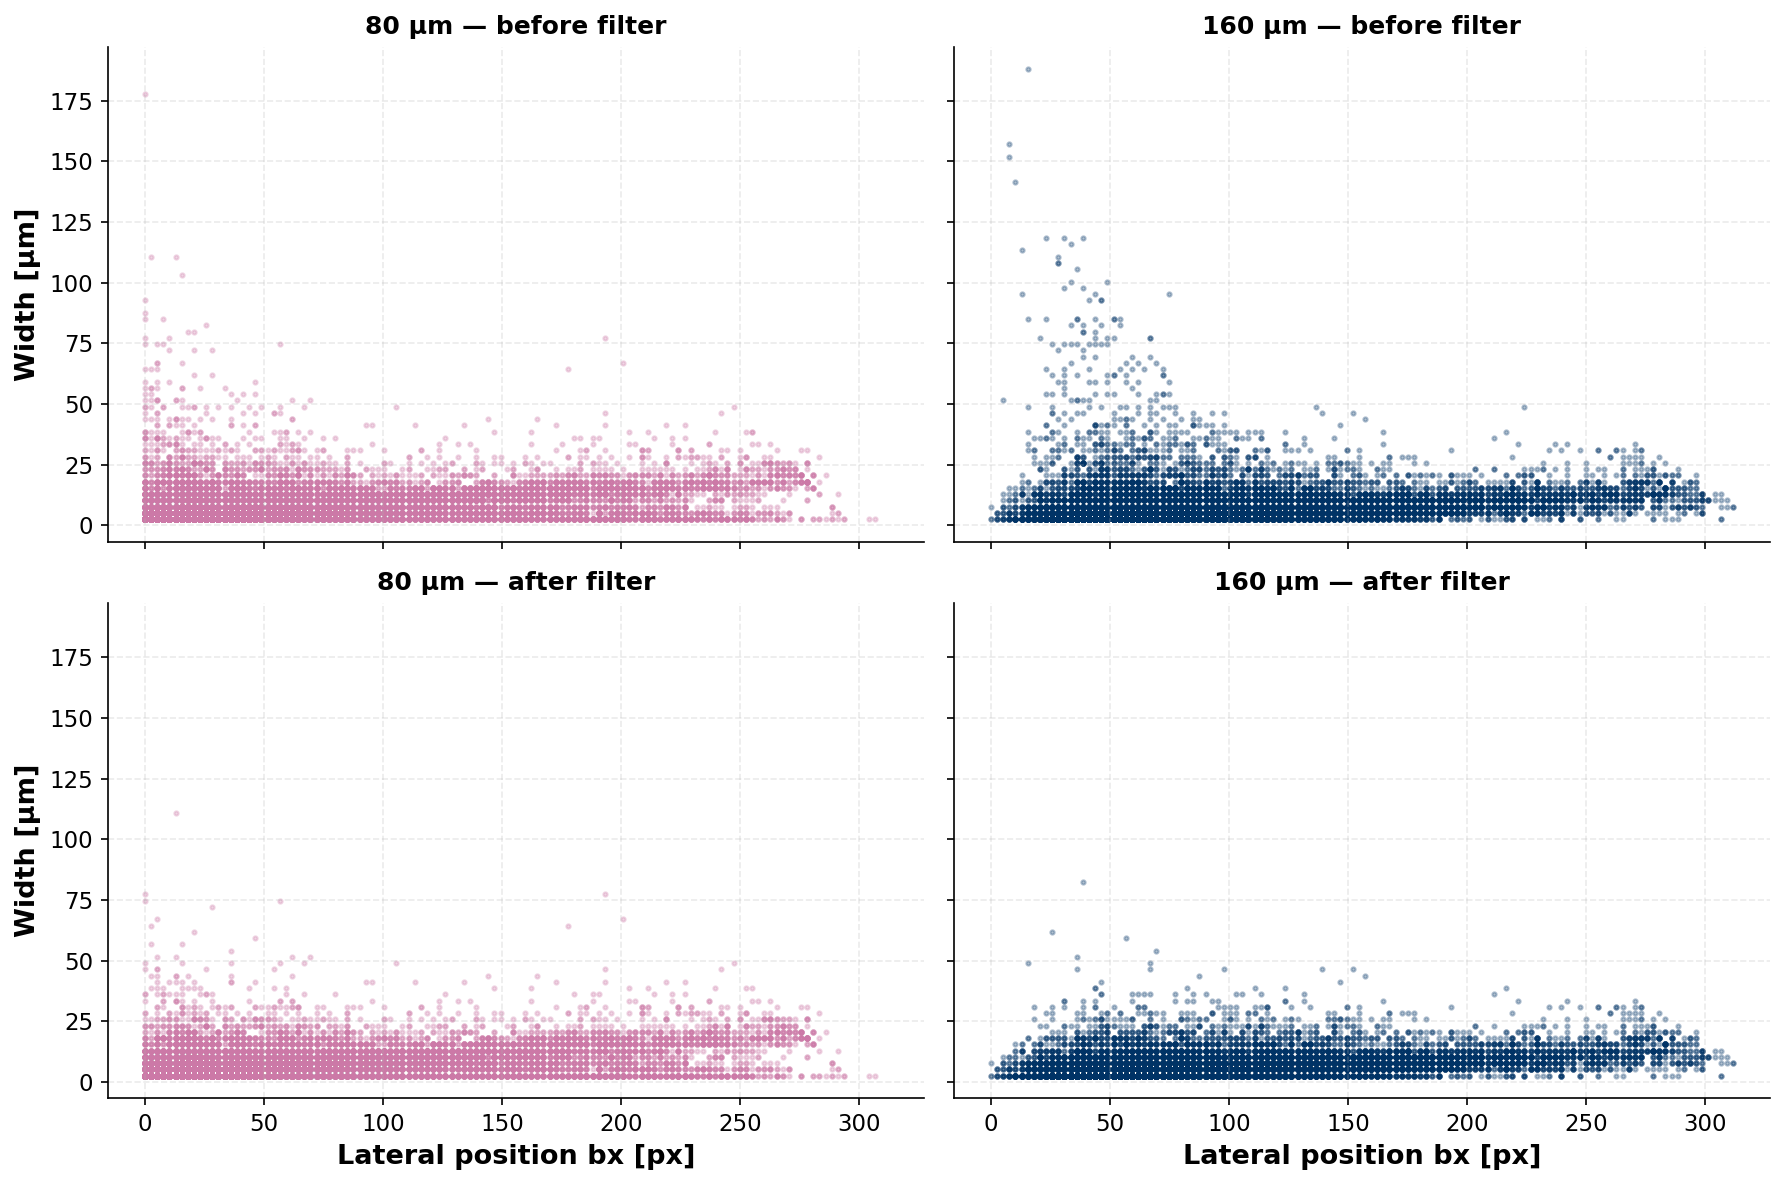

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for col_idx, design in enumerate(designs):
    color = DESIGN_COLOR[design]
    df_w  = exp_pre[(exp_pre["design"] == design) & (exp_pre["branch"] == "waste")]

    ax_b = axes[0, col_idx]
    ax_b.scatter(df_w["bx"], df_w["width"], s=4, alpha=0.3, color=color)
    ax_b.set_title(f"{DESIGN_STYLE[design]['label']} — before filter",
                   fontsize=12, fontweight="bold")

    ax_a = axes[1, col_idx]
    df_w_kept = df_w[~df_w["is_artefact"]]
    ax_a.scatter(df_w_kept["bx"], df_w_kept["width"], s=4, alpha=0.3, color=color)
    ax_a.set_title(f"{DESIGN_STYLE[design]['label']} — after filter",
                   fontsize=12, fontweight="bold")

for ax in axes[-1, :]:
    ax.set_xlabel("Lateral position bx [px]", fontsize=13, fontweight="bold")
for ax in axes[:, 0]:
    ax.set_ylabel("Width [µm]", fontsize=13, fontweight="bold")
for ax in axes.flatten():
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("fig_exp_waste_filter.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# ── Minimum collection sample size criterion ─────────────────────────────────
# Conditions with fewer than MIN_COLL_N collection particles are excluded as
# the metrics they yield are not statistically reliable.
MIN_COLL_N = 15

# Count collection particles per (design, flow_v2_round) condition
coll_counts = (
    exp_df[exp_df["branch"] == "collection"]
    .groupby(["design", "flow_v2_round"])
    .size()
    .reset_index(name="n_coll")
)

# Identify which conditions to keep
valid_conditions = coll_counts[coll_counts["n_coll"] >= MIN_COLL_N][
    ["design", "flow_v2_round"]
]
n_before = len(exp_df)

# Apply the filter to exp_df (both branches, so as not to break the waste-side balance)
exp_df = exp_df.merge(valid_conditions, on=["design", "flow_v2_round"])
n_after = len(exp_df)

# Report which conditions were dropped
dropped = coll_counts[coll_counts["n_coll"] < MIN_COLL_N]
print(f"Excluded conditions (n_coll < {MIN_COLL_N}):")
print(dropped.to_string(index=False))
print(f"\nParticles before: {n_before:,}")
print(f"Particles after:  {n_after:,}")

# Update wash_rates list to reflect the filtered data
wash_rates = sorted(exp_df["flow_v2_round"].unique())
n_rates    = len(wash_rates)

Excluded conditions (n_coll < 15):
   design  flow_v2_round  n_coll
80um_3out             12       6
80um_3out             22      14

Particles before: 33,489
Particles after:  32,626


---
## 3. KDE distributions per design × outlet

Pooled (across devices, with runs already combined within each device) KDE of particle diameter distributions, one figure per outlet. Each figure shows both designs side by side with curves colour-coded by wash flow rate.

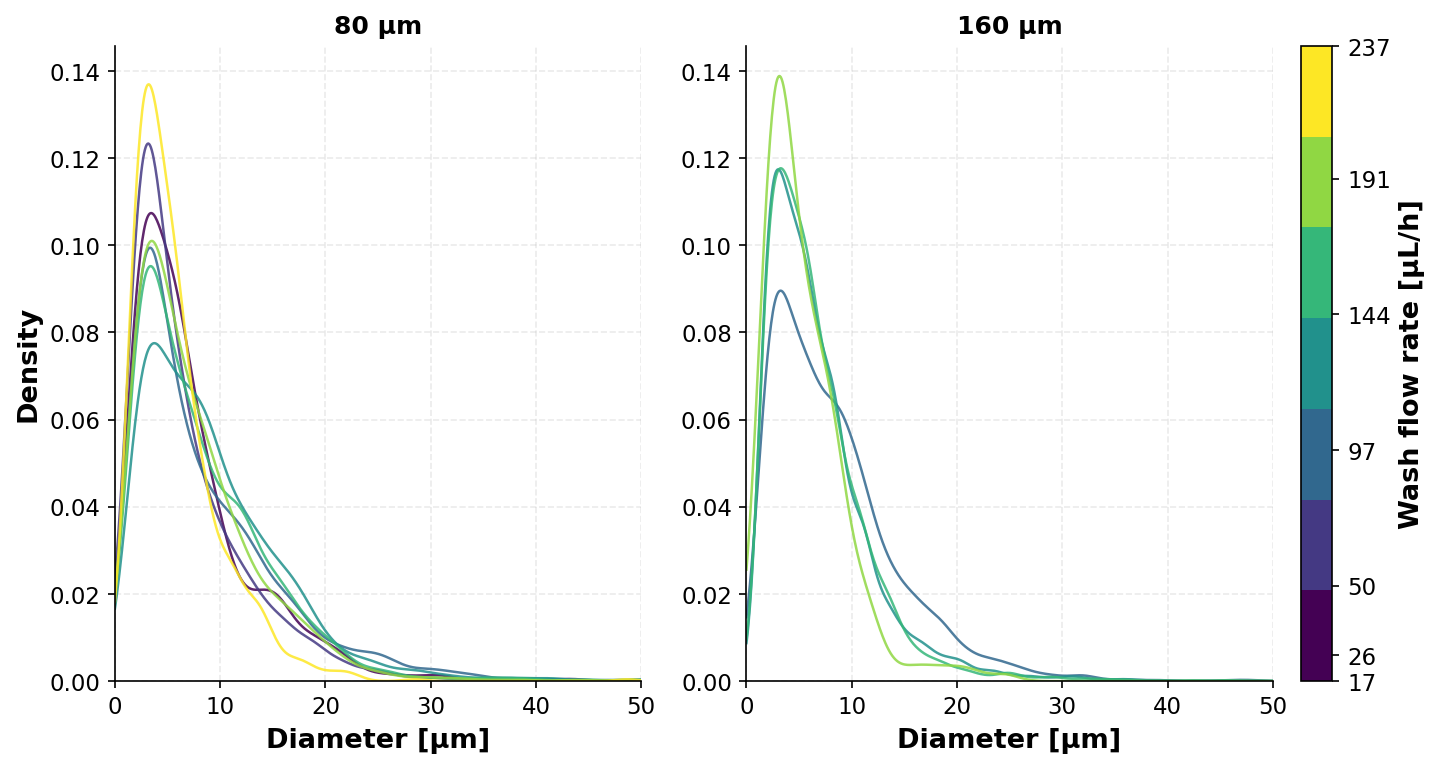

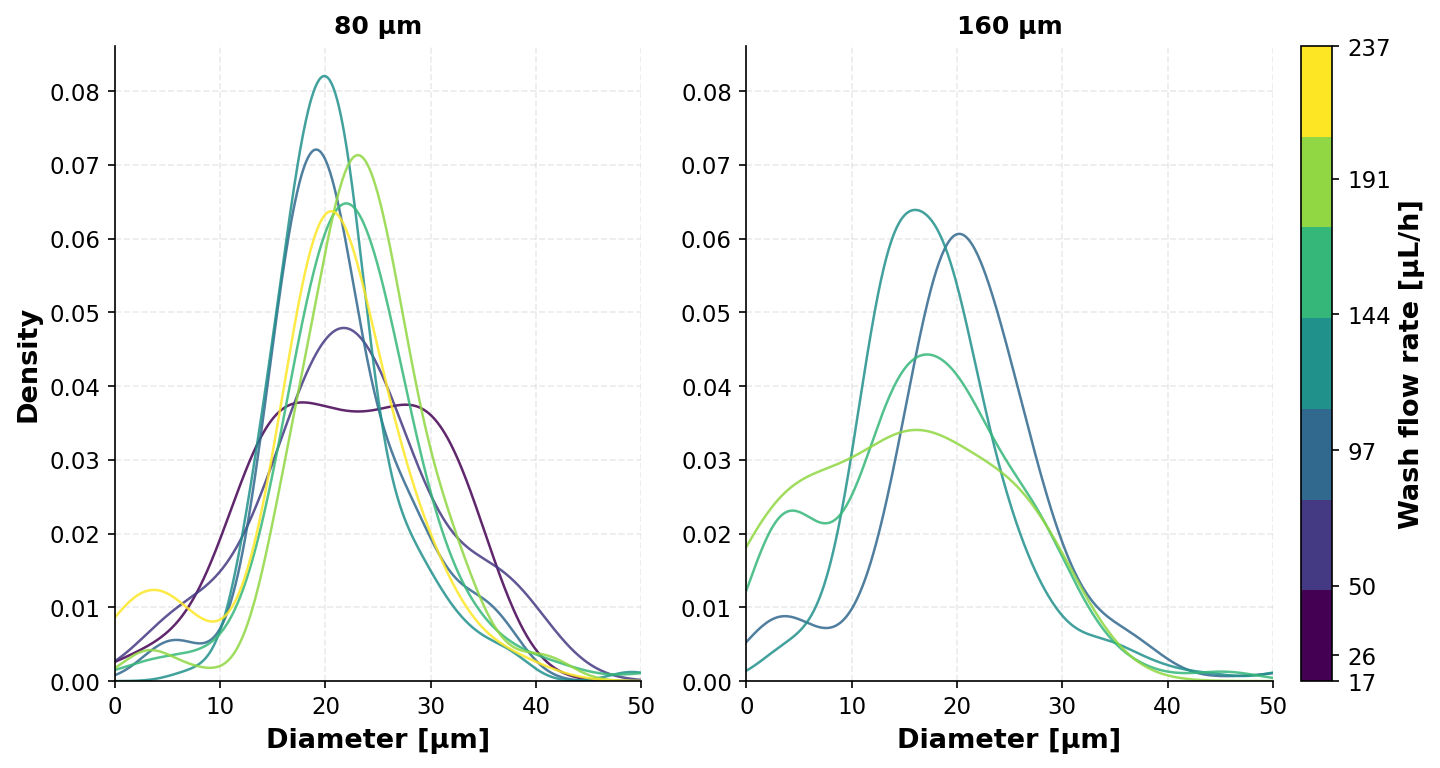

In [ ]:
cmap        = matplotlib.colormaps["viridis"].resampled(n_rates)
rate_colors = {v2: cmap(i) for i, v2 in enumerate(wash_rates)}

x_eval = np.linspace(0, 50, 600)
X_LIM  = (0, 50)

def add_colorbar(fig, axes, cmap, wash_rates):
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=min(wash_rates), vmax=max(wash_rates))
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=1.0, pad=0.02)
    cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
    cbar.set_ticks(wash_rates)
    cbar.ax.tick_params(labelsize=11)

# Pre-compute global y-limits per branch
y_max = {"waste": 0.0, "collection": 0.0}
for design in designs:
    for v2 in wash_rates:
        df_v = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
        for branch in ("waste", "collection"):
            vals = df_v[df_v["branch"] == branch]["width"].values
            if len(vals) > 1:
                y_max[branch] = max(y_max[branch], jittered_kde(vals)(x_eval).max())
Y_LIM = {b: (0, y_max[b] * 1.05) for b in y_max}

for branch, title in [("waste", "Waste outlet"), ("collection", "Collection outlet")]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    for ax, design in zip(axes, designs):
        df_d = exp_df[(exp_df["design"] == design) & (exp_df["branch"] == branch)]
        for v2 in wash_rates:
            vals = df_d[df_d["flow_v2_round"] == v2]["width"].values
            if len(vals) > 1:
                kde = jittered_kde(vals)
                ax.plot(x_eval, kde(x_eval),
                        color=rate_colors[v2],
                        #linestyle=DESIGN_STYLE[design]["linestyle"],
                        linewidth=1.2, alpha=0.85)
        ax.set_title(DESIGN_STYLE[design]["label"], fontsize=12, fontweight="bold")
        ax.set_xlabel("Diameter [µm]", fontsize=13, fontweight="bold")
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM[branch])
        ax.tick_params(labelsize=11)
    axes[0].set_ylabel("Density", fontsize=13, fontweight="bold")
    add_colorbar(fig, axes, cmap, wash_rates)
    #plt.tight_layout()
    plt.savefig(f"fig_exp_kde_{branch}.pdf", bbox_inches="tight")
    plt.show()

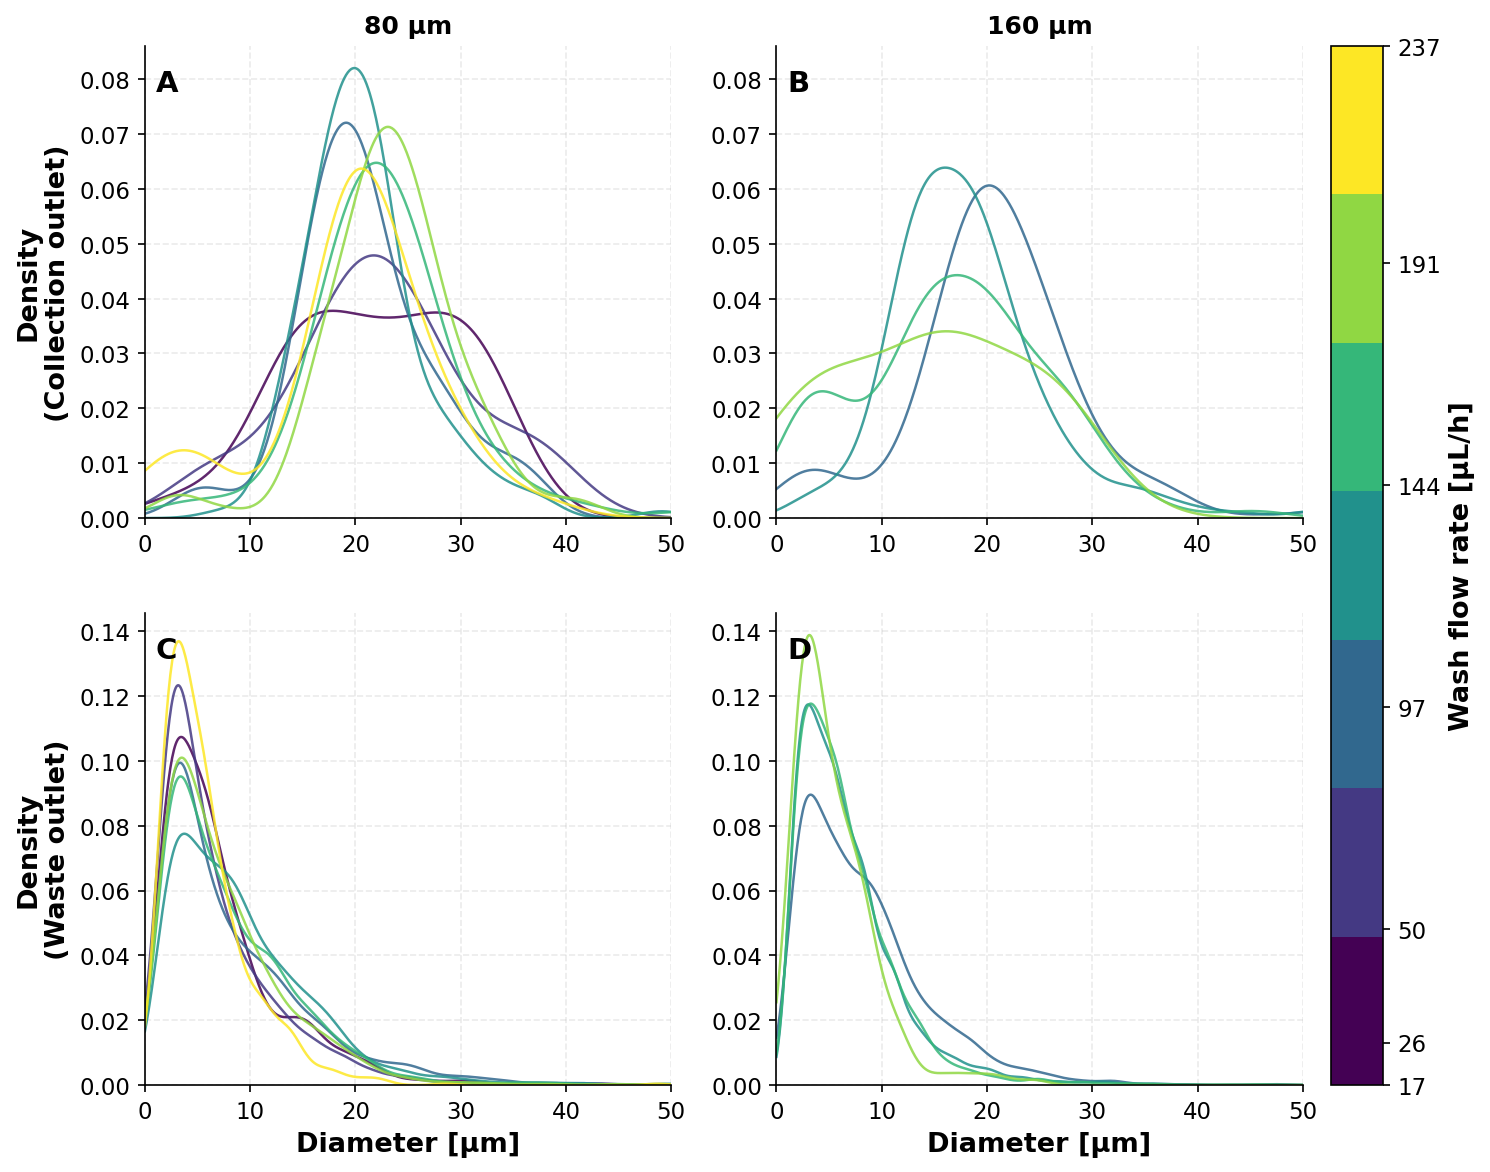

In [ ]:
cmap        = matplotlib.colormaps["viridis"].resampled(n_rates)
rate_colors = {v2: cmap(i) for i, v2 in enumerate(wash_rates)}

x_eval = np.linspace(0, 50, 600)
X_LIM  = (0, 50)

def add_colorbar(fig, axes, cmap, wash_rates):
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=min(wash_rates), vmax=max(wash_rates))
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=1.0, pad=0.02)
    cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
    cbar.set_ticks(wash_rates)
    cbar.ax.tick_params(labelsize=11)

# Pre-compute global y-limits per branch
y_max = {"waste": 0.0, "collection": 0.0}
for design in designs:
    for v2 in wash_rates:
        df_v = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
        for branch in ("waste", "collection"):
            vals = df_v[df_v["branch"] == branch]["width"].values
            if len(vals) > 1:
                y_max[branch] = max(y_max[branch], jittered_kde(vals)(x_eval).max())
Y_LIM = {b: (0, y_max[b] * 1.05) for b in y_max}

# ── Combined figure: Waste (top row) + Collection (bottom row) ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Configuration for each row: (branch key, y-limit, row label)
rows = [
    ("collection", Y_LIM["collection"], "Collection outlet"),
    ("waste",      Y_LIM["waste"],      "Waste outlet"),
]

# Panel labels (A) (B) (C) (D)
panel_labels = [["A", "B"], ["C", "D"]]

for row_idx, (branch, y_lim, row_label) in enumerate(rows):
    for col_idx, design in enumerate(designs):
        ax   = axes[row_idx, col_idx]
        df_d = exp_df[(exp_df["design"] == design) & (exp_df["branch"] == branch)]

        for v2 in wash_rates:
            vals = df_d[df_d["flow_v2_round"] == v2]["width"].values
            if len(vals) > 1:
                kde = jittered_kde(vals)
                ax.plot(x_eval, kde(x_eval),
                        color=rate_colors[v2],
                        linewidth=1.2, alpha=0.85)

        # Panel label (A, B, C, D) in the top-left corner
        ax.text(0.02, 0.95, panel_labels[row_idx][col_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold",
                va="top", ha="left")

        # Design title only on top row
        if row_idx == 0:
            ax.set_title(DESIGN_STYLE[design]["label"],
                         fontsize=12, fontweight="bold")

        # X-label only on bottom row
        if row_idx == len(rows) - 1:
            ax.set_xlabel("Diameter [µm]", fontsize=13, fontweight="bold")

        # Y-label only on leftmost column, including branch identification
        if col_idx == 0:
            ax.set_ylabel(f"Density\n({row_label})",
                          fontsize=13, fontweight="bold")

        ax.set_xlim(X_LIM)
        ax.set_ylim(y_lim)
        ax.tick_params(labelsize=11)

# Single shared colorbar for all four panels
add_colorbar(fig, axes.ravel().tolist(), cmap, wash_rates)

plt.savefig("fig_exp_kde_combined.pdf", bbox_inches="tight")
plt.show()

---
## 4. KDE grid per wash flow rate with d★ overlay

One subplot per wash flow rate. Each panel shows waste and collection KDEs for both designs, with vertical lines marking the pooled–pooled d★ (intersection of pooled waste and pooled collection KDEs).

In [ ]:
def find_kde_intersection_exp(waste, clean, xmin=0, xmax=50, n=1000, seed=42):
    """First KDE intersection (sub-pixel-jittered KDEs)."""
    waste = np.asarray(waste); clean = np.asarray(clean)
    if len(waste) < 2 or len(clean) < 2:
        return None
    kde_w = jittered_kde(waste, seed=seed)
    kde_c = jittered_kde(clean, seed=seed + 1)
    x     = np.linspace(xmin, xmax, n)
    diff  = kde_w(x) - kde_c(x)
    sc    = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    i = sc[0]
    x0, x1 = x[i], x[i + 1]
    y0, y1 = diff[i], diff[i + 1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)

def find_kde_intersection_nth(waste, clean, n_crossing=1,
                               xmin=0, xmax=50, n=1000, seed=42):
    """Nth KDE intersection (1 = first, 2 = second, etc.)."""
    waste = np.asarray(waste); clean = np.asarray(clean)
    if len(waste) < 2 or len(clean) < 2:
        return None
    kde_w = jittered_kde(waste, seed=seed)
    kde_c = jittered_kde(clean, seed=seed + 1)
    x     = np.linspace(xmin, xmax, n)
    diff  = kde_w(x) - kde_c(x)
    sc    = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) < n_crossing:
        return None
    i = sc[n_crossing - 1]
    x0, x1 = x[i], x[i + 1]
    y0, y1 = diff[i], diff[i + 1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)

In [ ]:
# Pooled–pooled d★ per design × wash flow rate
pooled_dstar_records = []
for design in designs:
    df_design = exp_df[exp_df["design"] == design]
    for v2 in wash_rates:
        df_dv = df_design[df_design["flow_v2_round"] == v2]
        waste = df_dv[df_dv["branch"] == "waste"]["width"].values
        coll  = df_dv[df_dv["branch"] == "collection"]["width"].values
        d_star = find_kde_intersection_exp(waste, coll)
        pooled_dstar_records.append({
            "design":  design, "flow_v2": v2, "d_star": d_star,
            "n_waste": len(waste), "n_coll": len(coll),
        })
pooled_dstar = pd.DataFrame(pooled_dstar_records)

# Manual overrides for pooled–pooled d★ if needed.
# Inspect the KDE grid (next cell) and add overrides here if any d★ value
# does not match the visible bulk crossover. Format:
# (design, flow_v2): n_crossing
MANUAL_POOLED_OVERRIDES = {
     ("160um_3out", 144): 2,
}
for (design, v2), n_cross in MANUAL_POOLED_OVERRIDES.items():
    df_dv = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
    waste = df_dv[df_dv["branch"] == "waste"]["width"].values
    coll  = df_dv[df_dv["branch"] == "collection"]["width"].values
    new_d = find_kde_intersection_nth(waste, coll, n_crossing=n_cross)
    pooled_dstar.loc[
        (pooled_dstar["design"] == design) & (pooled_dstar["flow_v2"] == v2),
        "d_star"
    ] = new_d

print(pooled_dstar.to_string(index=False))

    design  flow_v2    d_star  n_waste  n_coll
 80um_3out       17 11.671337     1408      34
 80um_3out       26 13.005161     1528      35
 80um_3out       50 13.488278     3654      79
 80um_3out       97 13.841507     2958     153
 80um_3out      144 14.831859     2522     159
 80um_3out      191 14.908846     2577     124
 80um_3out      237 13.035333      903      38
160um_3out       17       NaN        0       0
160um_3out       26       NaN        0       0
160um_3out       50 13.680744     3635     233
160um_3out       97 10.791252     6750     454
160um_3out      144 11.664746     4851     303
160um_3out      191 10.436419      211      17
160um_3out      237       NaN        0       0


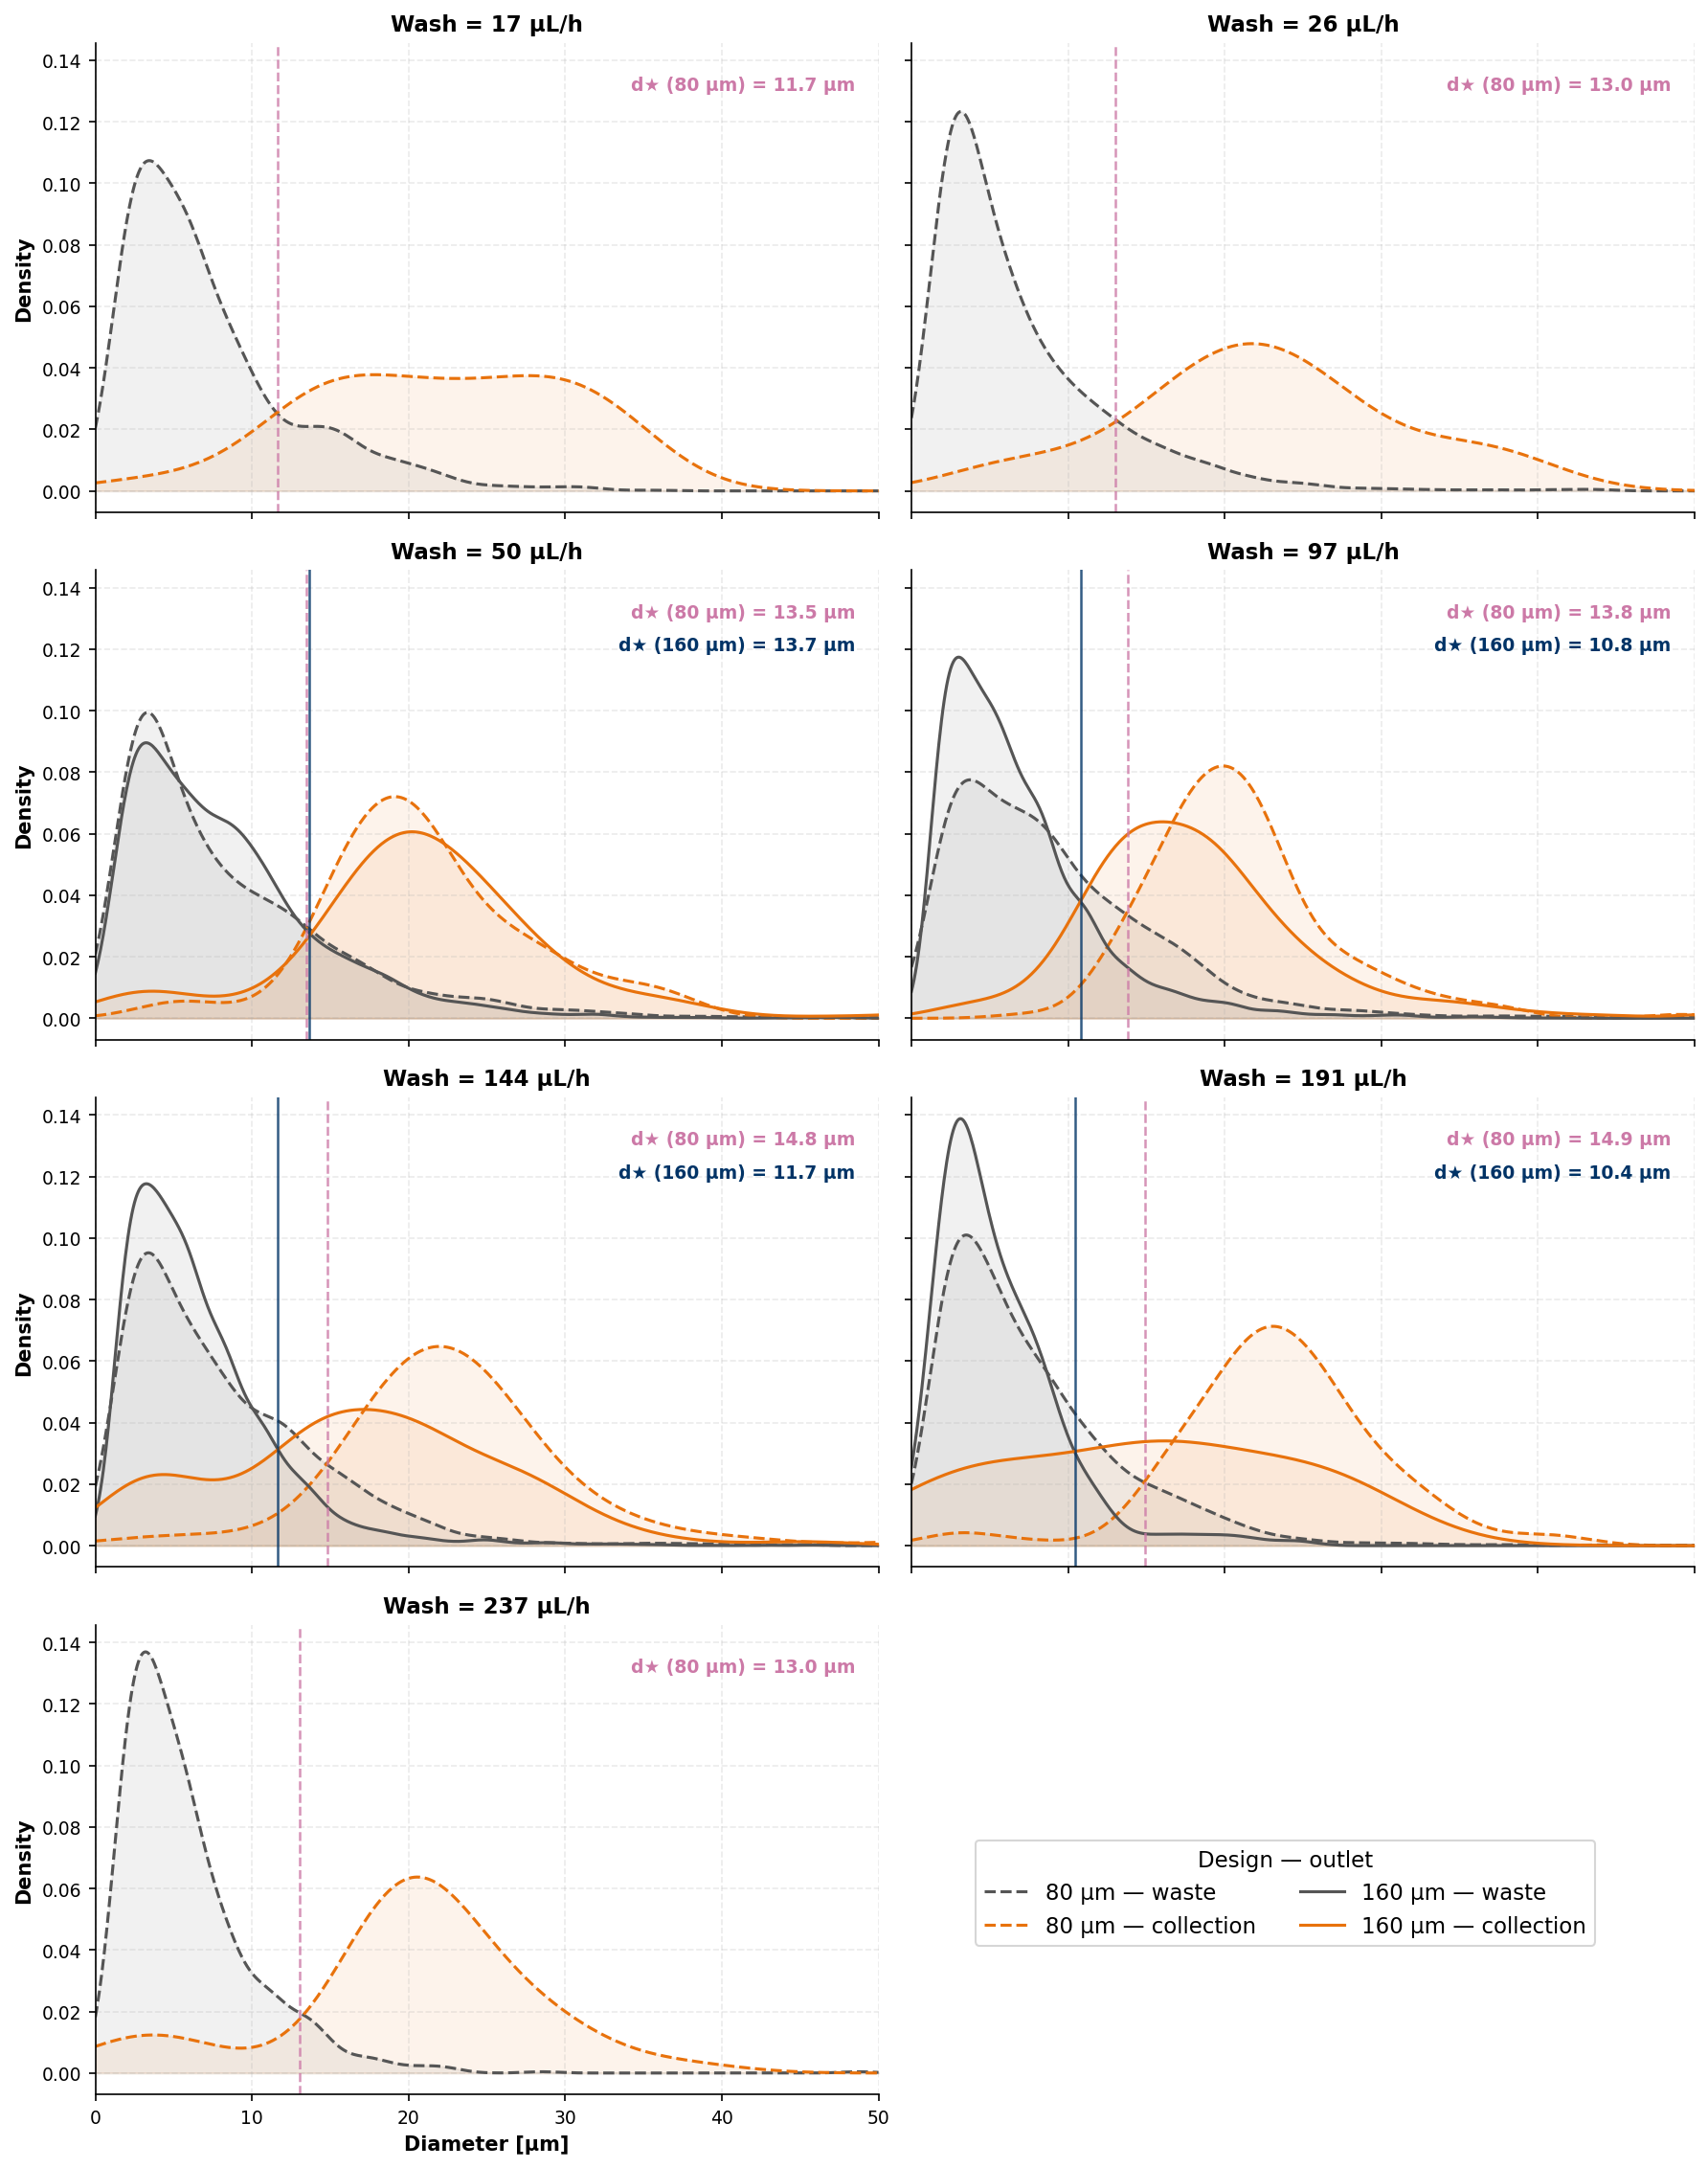

In [ ]:
ncols = 2
nrows = math.ceil(n_rates / ncols)
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(12, 3.8 * nrows),
                          sharex=True, sharey=True)
axes_flat = np.array(axes).flatten()

for idx, v2 in enumerate(wash_rates):
    ax = axes_flat[idx]
    for design in designs:
        ls   = DESIGN_STYLE[design]["linestyle"]
        df_v = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
        waste = df_v[df_v["branch"] == "waste"]["width"].values
        coll  = df_v[df_v["branch"] == "collection"]["width"].values

        if len(waste) > 1:
            kde = jittered_kde(waste)
            ax.plot(x_eval, kde(x_eval),
                    color=COL_WASTE, linestyle=ls, linewidth=1.5)
            ax.fill_between(x_eval, kde(x_eval), color=COL_WASTE, alpha=0.08)
        if len(coll) > 1:
            kde = jittered_kde(coll)
            ax.plot(x_eval, kde(x_eval),
                    color=COL_COLLECTION, linestyle=ls, linewidth=1.5)
            ax.fill_between(x_eval, kde(x_eval), color=COL_COLLECTION, alpha=0.08)

    dstar_entries = []
    for design in designs:
        row_d = pooled_dstar[
            (pooled_dstar["design"]  == design) &
            (pooled_dstar["flow_v2"] == v2)
        ]
        if not row_d.empty and row_d["d_star"].notna().any():
            d_val = row_d["d_star"].values[0]
            ax.axvline(d_val,
                       color=DESIGN_COLOR[design],
                       linestyle=DESIGN_STYLE[design]["linestyle"],
                       linewidth=1.2, alpha=0.8)
            dstar_entries.append((design, d_val))

    for i, (design, d_val) in enumerate(dstar_entries):
        ax.text(0.97, 0.93 - i * 0.07,
                f"d★ ({DESIGN_STYLE[design]['label']}) = {d_val:.1f} µm",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=9,
                color=DESIGN_COLOR[design],
                fontweight="bold")

    ax.set_title(f"Wash = {v2} µL/h", fontsize=11, fontweight="bold")
    ax.set_xlim(0, 50)
    ax.tick_params(labelsize=9)

for ax in axes_flat[n_rates:]:
    fig.delaxes(ax)
for ax in axes_flat[(nrows - 1) * ncols : n_rates]:
    ax.set_xlabel("Diameter [µm]", fontsize=10, fontweight="bold")
for i in range(0, n_rates, ncols):
    axes_flat[i].set_ylabel("Density", fontsize=10, fontweight="bold")

legend_handles = []
for design in designs:
    ls  = DESIGN_STYLE[design]["linestyle"]
    lbl = DESIGN_STYLE[design]["label"]
    legend_handles += [
        Line2D([0], [0], color=COL_WASTE, linestyle=ls,
               linewidth=1.5, label=f"{lbl} — waste"),
        Line2D([0], [0], color=COL_COLLECTION, linestyle=ls,
               linewidth=1.5, label=f"{lbl} — collection"),
    ]
fig.legend(handles=legend_handles,
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.75, 0.1),
           framealpha=0.8, title="Design — outlet",
           title_fontsize=11, fontsize=11)
plt.tight_layout()
plt.savefig("fig_exp_kde_grid.pdf", bbox_inches="tight")
plt.show()

---
## 5. Experimental d★ vs wash flow rate (per-device)

Per-device d★: for each device, all runs are pooled and the device's collection KDE is intersected against the pooled-across-all-devices waste KDE (the latter chosen as a stable, well-sampled reference). Mean ± SD across devices is reported. Single-device conditions are shown as open markers (still connected by the trend line) and contribute no error bar.

In [ ]:
# Per-device d★
dstar_perdev_records = []
for design in designs:
    df_design = exp_df[exp_df["design"] == design]
    for v2 in wash_rates:
        df_dv = df_design[df_design["flow_v2_round"] == v2]
        waste_pooled = df_dv[df_dv["branch"] == "waste"]["width"].values
        if len(waste_pooled) < 2:
            continue
        coll_per_device = df_dv[df_dv["branch"] == "collection"]
        for device_id, df_dev in coll_per_device.groupby("device_id"):
            coll = df_dev["width"].values
            if len(coll) < 5:
                continue
            d_star = find_kde_intersection_exp(waste_pooled, coll)
            dstar_perdev_records.append({
                "design":    design,
                "flow_v2":   v2,
                "device_id": device_id,
                "d_star":    d_star,
                "n_coll":    len(coll),
            })
dstar_perdev = pd.DataFrame(dstar_perdev_records)

# Manual per-device overrides. Inspect per-device KDE plots if needed.
# Format: (design, flow_v2, device_id): n_crossing
MANUAL_PERDEV_OVERRIDES = {
     ("160um_3out", 144, "160um_3out_dev2"): 2,
     ("80um_3out", 237, "80um_3out_dev2"): 2,
}
for (design, v2, dev), n_cross in MANUAL_PERDEV_OVERRIDES.items():
    df_dv = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
    waste_p = df_dv[df_dv["branch"] == "waste"]["width"].values
    coll    = df_dv[
        (df_dv["device_id"] == dev) & (df_dv["branch"] == "collection")
    ]["width"].values
    new_d = find_kde_intersection_nth(waste_p, coll, n_crossing=n_cross)
    mask = (
        (dstar_perdev["design"]    == design) &
        (dstar_perdev["flow_v2"]   == v2) &
        (dstar_perdev["device_id"] == dev)
    )
    dstar_perdev.loc[mask, "d_star"] = new_d

# Aggregate per design × flow_v2
dstar_summary = (
    dstar_perdev
    .dropna(subset=["d_star"])
    .groupby(["design", "flow_v2"])
    .agg(
        d_star_mean=("d_star", "mean"),
        d_star_sd  =("d_star", "std"),
        n_devices  =("device_id", "nunique"),
    )
    .reset_index()
)
print(dstar_summary.to_string(index=False))

    design  flow_v2  d_star_mean  d_star_sd  n_devices
160um_3out       50    13.840149   2.081082          2
160um_3out       97    10.996938   1.246108          3
160um_3out      144    11.743297   1.658235          3
160um_3out      191    10.436419        NaN          1
 80um_3out       17    13.587145   2.839617          2
 80um_3out       26    13.053544   0.671403          2
 80um_3out       50    15.229652   2.782471          2
 80um_3out       97    15.307634   2.951754          3
 80um_3out      144    15.360969   1.056690          3
 80um_3out      191    15.220690   1.899547          3
 80um_3out      237    12.114544   1.364211          2


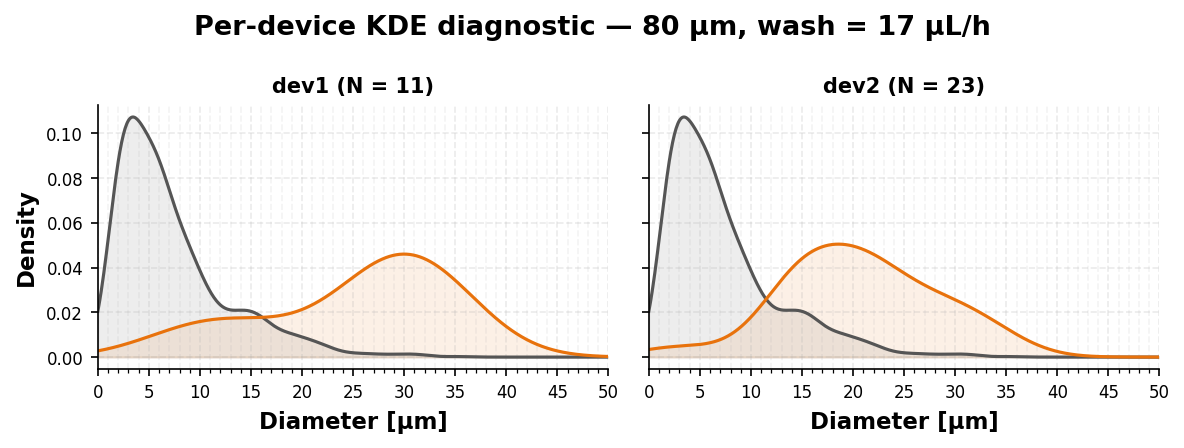

In [ ]:
# ── Per-device KDE diagnostic for problematic conditions ──────────────────────
# Inspect each device's collection KDE against the pooled waste KDE
# to identify which devices have the wrong crossing being picked.

DIAGNOSTIC_CONDITIONS = [
    ("80um_3out", 17),
    ("80um_3out", 22),
]

x_eval = np.linspace(0, 50, 600)

for design, v2 in DIAGNOSTIC_CONDITIONS:
    df_dv = exp_df[
        (exp_df["design"]        == design) &
        (exp_df["flow_v2_round"] == v2)
    ]

    waste_pooled = df_dv[df_dv["branch"] == "waste"]["width"].values
    coll_devices = df_dv[df_dv["branch"] == "collection"]
    device_ids   = sorted(coll_devices["device_id"].unique())

    if len(waste_pooled) < 2 or not device_ids:
        continue

    kde_w_pooled = jittered_kde(waste_pooled)
    yw_pooled    = kde_w_pooled(x_eval)

    ncols = min(3, len(device_ids))
    nrows = math.ceil(len(device_ids) / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4 * ncols, 3 * nrows),
                              sharex=True, sharey=True)
    axes_flat = np.array(axes).flatten() if nrows * ncols > 1 else np.array([axes])

    for idx, device_id in enumerate(device_ids):
        ax = axes_flat[idx]
        vals = coll_devices[coll_devices["device_id"] == device_id]["width"].values

        ax.plot(x_eval, yw_pooled,
                color=COL_WASTE, linewidth=1.5, label="Waste (pooled)")
        ax.fill_between(x_eval, yw_pooled, color=COL_WASTE, alpha=0.1)

        if len(vals) >= 2:
            kde_c = jittered_kde(vals)
            yc    = kde_c(x_eval)
            ax.plot(x_eval, yc,
                    color=COL_COLLECTION, linewidth=1.5, label="Collection")
            ax.fill_between(x_eval, yc, color=COL_COLLECTION, alpha=0.1)

        ax.set_xticks(np.arange(0, 51, 5))
        ax.set_xticks(np.arange(0, 51, 1), minor=True)
        ax.grid(which="minor", alpha=0.15)

        short_label = device_id.replace(f"{design}_", "")
        ax.set_title(f"{short_label} (N = {len(vals)})",
                     fontsize=10, fontweight="bold")
        ax.set_xlim(0, 50)
        ax.tick_params(labelsize=8)

    for ax in axes_flat[len(device_ids):]:
        fig.delaxes(ax)

    for ax in axes_flat[(nrows - 1) * ncols : len(device_ids)]:
        ax.set_xlabel("Diameter [µm]", fontsize=11, fontweight="bold")
    for i in range(0, len(device_ids), ncols):
        axes_flat[i].set_ylabel("Density", fontsize=11, fontweight="bold")

    fig.suptitle(
        f"Per-device KDE diagnostic — {DESIGN_STYLE[design]['label']}, wash = {v2} µL/h",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"fig_per_device_diagnostic_{design}_{v2}.pdf",
                bbox_inches="tight")
    plt.show()

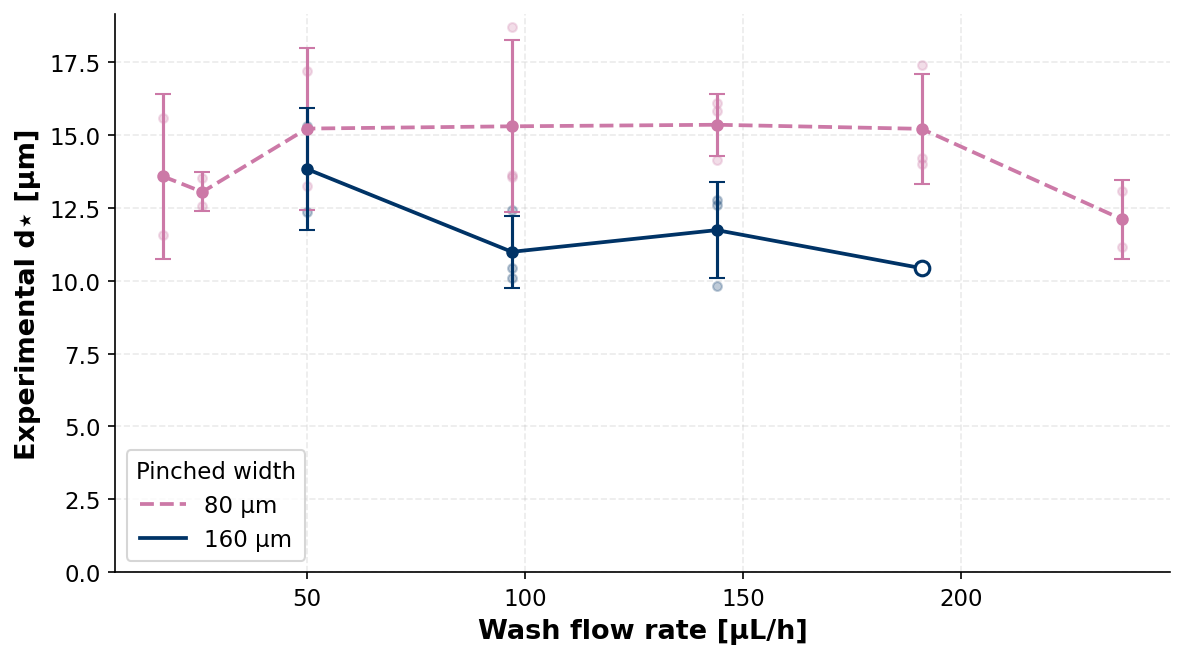

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for design in designs:
    color = DESIGN_COLOR[design]
    ls    = DESIGN_STYLE[design]["linestyle"]
    label = DESIGN_STYLE[design]["label"]

    df_d = dstar_summary[dstar_summary["design"] == design].sort_values("flow_v2")

    # Connecting line (through ALL points, multi + single device)
    ax.plot(df_d["flow_v2"], df_d["d_star_mean"],
            color=color, linestyle=ls, linewidth=1.8, zorder=2, label=label)

    # Per-device individual points (faint scatter)
    df_pts = dstar_perdev[
        (dstar_perdev["design"] == design) & dstar_perdev["d_star"].notna()
    ]
    ax.scatter(df_pts["flow_v2"], df_pts["d_star"],
               color=color, alpha=0.25, s=18, zorder=2)

    # Multi-device markers: filled, with error bars
    df_multi = df_d[df_d["n_devices"] >= 2]
    if not df_multi.empty:
        ax.errorbar(
            df_multi["flow_v2"], df_multi["d_star_mean"],
            yerr=df_multi["d_star_sd"],
            color=color, linestyle="none",
            marker="o", markersize=5, capsize=4, zorder=3
        )

    # Single-device markers: open, no error bar
    df_single = df_d[df_d["n_devices"] == 1]
    if not df_single.empty:
        ax.plot(df_single["flow_v2"], df_single["d_star_mean"],
                marker="o", markersize=7,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=1.5,
                linestyle="none", zorder=3)

ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
ax.set_ylabel("Experimental d⋆ [µm]", fontsize=13, fontweight="bold")
ax.tick_params(labelsize=11)
ax.set_ylim(bottom=0)

legend_handles = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8,
           #marker="o", markersize=5,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
#legend_handles.append(
    #Line2D([0], [0], marker="o", markerfacecolor="white",
     #      markeredgecolor="grey", linestyle="none",
      #     markersize=8,
       #    label="Single device")
#)
ax.legend(handles=legend_handles, title="Pinched width",
          title_fontsize=11, fontsize=11, framealpha=0.8)

plt.tight_layout()
plt.savefig("fig_exp_dstar_perdev.pdf", bbox_inches="tight")
plt.show()

---
## 6. Recovery and purity vs wash flow rate (per-device)

Per-device recovery and purity, computed by pooling all runs from a device into a single device-level sample, then computing the metric. Aggregated as mean ± SD across devices, with open markers for single-device conditions.

In [ ]:
def compute_metrics(df, guv_threshold):
    df = df.copy()
    df["is_GUV"] = df["width"] > guv_threshold
    collection = df[df["branch"] == "collection"]
    waste      = df[df["branch"] == "waste"]
    TP = collection[collection["is_GUV"]].shape[0]
    FN = waste[waste["is_GUV"]].shape[0]
    FP = collection[~collection["is_GUV"]].shape[0]
    if (TP + FN) == 0 or (TP + FP) == 0:
        return None
    return {"recovery": TP / (TP + FN), "purity": TP / (TP + FP)}

GUV_THRESHOLDS = {"Case 1 (> 10 µm)": 10, "Case 2 (> 15 µm)": 15}

perdev_metric_records = []
for case_label, thr in GUV_THRESHOLDS.items():
    for design in designs:
        for v2 in wash_rates:
            df_dv = exp_df[(exp_df["design"] == design) & (exp_df["flow_v2_round"] == v2)]
            for device_id, df_dev in df_dv.groupby("device_id"):
                m = compute_metrics(df_dev, thr)
                if m is None:
                    continue
                perdev_metric_records.append({
                    "case":      case_label,
                    "design":    design,
                    "flow_v2":   v2,
                    "device_id": device_id,
                    **m,
                })
perdev_metrics = pd.DataFrame(perdev_metric_records)

perdev_summary = (
    perdev_metrics
    .groupby(["case", "design", "flow_v2"])
    .agg(
        recovery_mean=("recovery", "mean"),
        recovery_sd  =("recovery", "std"),
        purity_mean  =("purity",   "mean"),
        purity_sd    =("purity",   "std"),
        n_devices    =("device_id", "nunique"),
    )
    .reset_index()
)
print(perdev_summary.to_string(index=False))

            case     design  flow_v2  recovery_mean  recovery_sd  purity_mean  purity_sd  n_devices
Case 1 (> 10 µm) 160um_3out       50       0.143697     0.025483     0.916999   0.036897          2
Case 1 (> 10 µm) 160um_3out       97       0.223513     0.076578     0.949689   0.011591          3
Case 1 (> 10 µm) 160um_3out      144       0.196956     0.071999     0.818712   0.137662          3
Case 1 (> 10 µm) 160um_3out      191       0.297297          NaN     0.647059        NaN          1
Case 1 (> 10 µm)  80um_3out       17       0.190940     0.186168     0.932806   0.033539          2
Case 1 (> 10 µm)  80um_3out       26       0.075164     0.047980     0.944444   0.078567          2
Case 1 (> 10 µm)  80um_3out       50       0.049520     0.024776     0.936248   0.066976          2
Case 1 (> 10 µm)  80um_3out       97       0.088900     0.064876     0.933333   0.115470          3
Case 1 (> 10 µm)  80um_3out      144       0.146184     0.103999     0.958170   0.026654          3


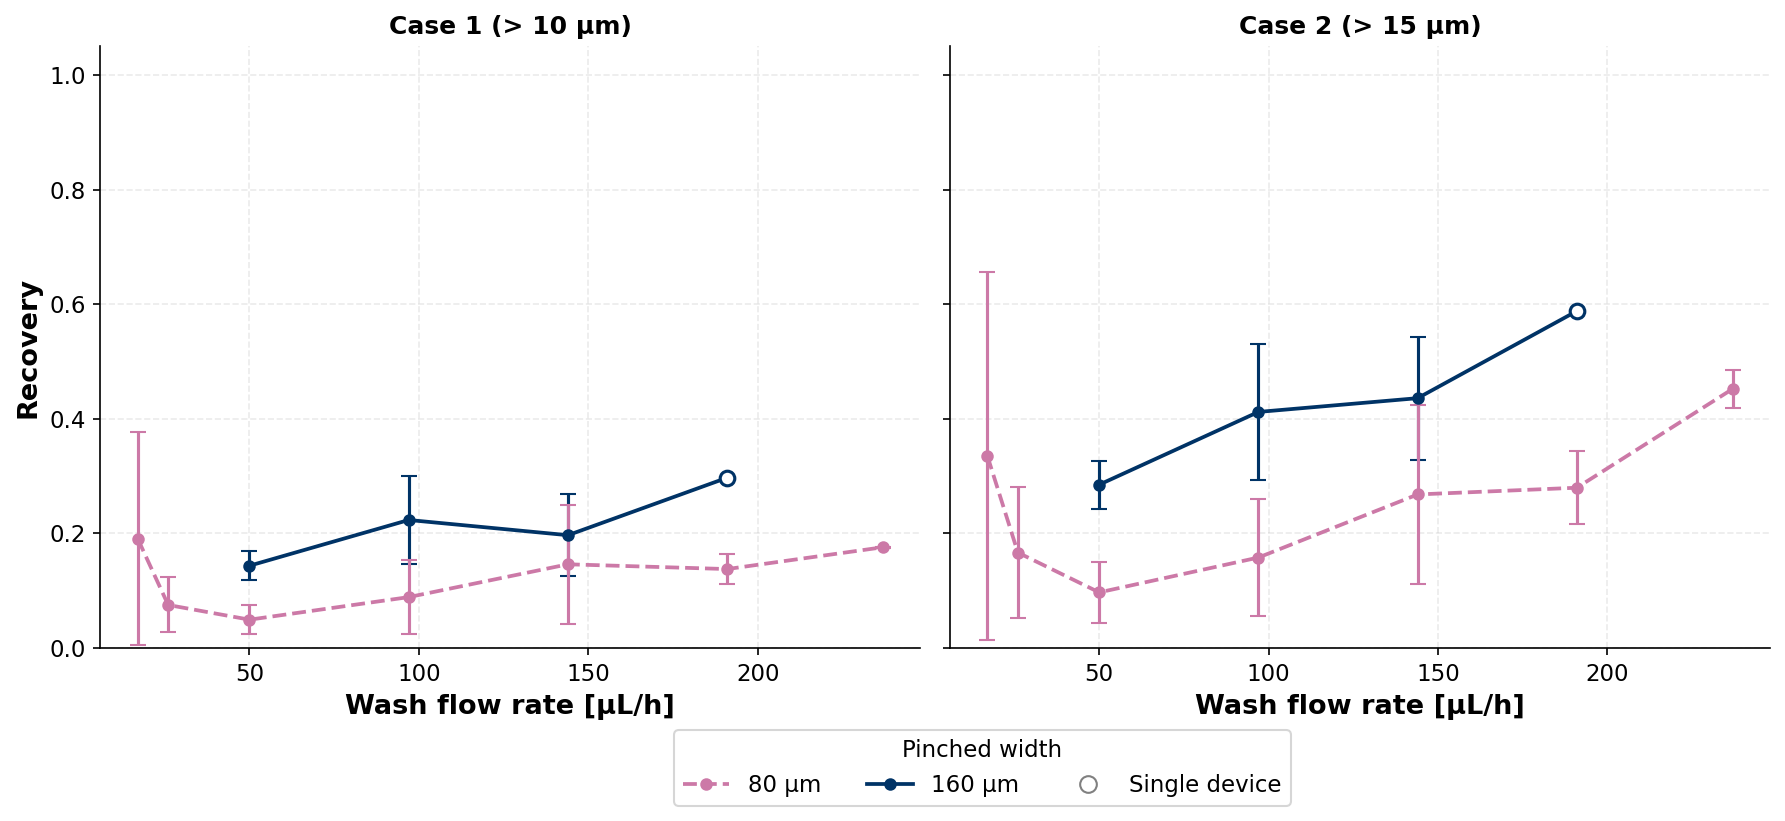

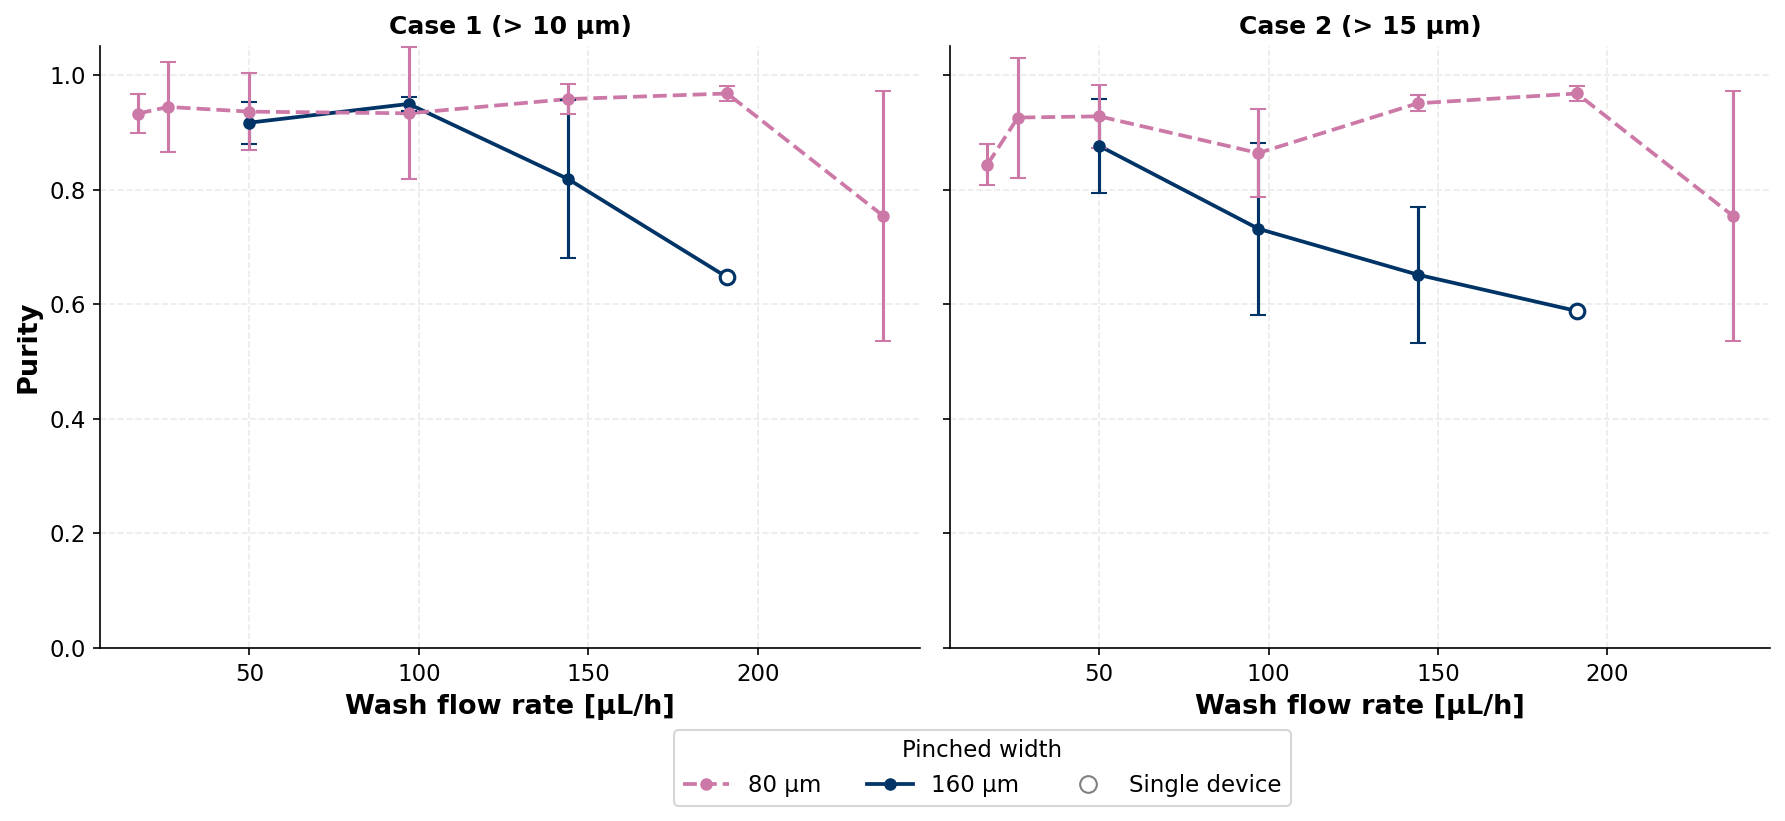

In [ ]:
metric_pairs = [
    ("recovery_mean", "recovery_sd", "Recovery"),
    ("purity_mean",   "purity_sd",   "Purity"),
]

legend_handles_metric = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=5,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
legend_handles_metric.append(
    Line2D([0], [0], marker="o", markerfacecolor="white",
           markeredgecolor="grey", linestyle="none", markersize=8,
           label="Single device")
)

for mean_col, sd_col, label in metric_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    cases = list(GUV_THRESHOLDS.keys())
    for ax, case in zip(axes, cases):
        df_case = perdev_summary[perdev_summary["case"] == case]
        for design in reversed(designs):
            color = DESIGN_COLOR[design]
            ls    = DESIGN_STYLE[design]["linestyle"]
            df_d  = df_case[df_case["design"] == design].sort_values("flow_v2")

            # Connecting line through all points
            ax.plot(df_d["flow_v2"], df_d[mean_col],
                    color=color, linestyle=ls, linewidth=1.8, zorder=2)

            # Multi-device
            df_multi = df_d[df_d["n_devices"] >= 2]
            if not df_multi.empty:
                ax.errorbar(
                    df_multi["flow_v2"], df_multi[mean_col],
                    yerr=df_multi[sd_col],
                    color=color, linestyle="none",
                    marker="o", markersize=5, capsize=4, zorder=3
                )

            # Single-device
            df_single = df_d[df_d["n_devices"] == 1]
            if not df_single.empty:
                ax.plot(df_single["flow_v2"], df_single[mean_col],
                        marker="o", markersize=7,
                        markerfacecolor="white",
                        markeredgecolor=color,
                        markeredgewidth=1.5,
                        linestyle="none", zorder=3)

        ax.set_title(case, fontsize=12, fontweight="bold")
        ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.tick_params(labelsize=11)
    axes[0].set_ylabel(label, fontsize=13, fontweight="bold")

    fig.legend(
        handles=legend_handles_metric, title="Pinched width",
        title_fontsize=11, fontsize=11, framealpha=0.8,
        loc="lower center", ncol=3,
        bbox_to_anchor=(0.55, -0.1)
    )
    plt.tight_layout()
    plt.savefig(f"fig_exp_{label.lower()}_perdev.pdf", bbox_inches="tight")
    plt.show()

---
## 7. Purity vs recovery trade-off

(Per-device mean values, one point per design × wash flow rate.) The trajectory in (purity, recovery) space reveals the trade-off between collection purity and GUV recovery as wash flow rate increases.

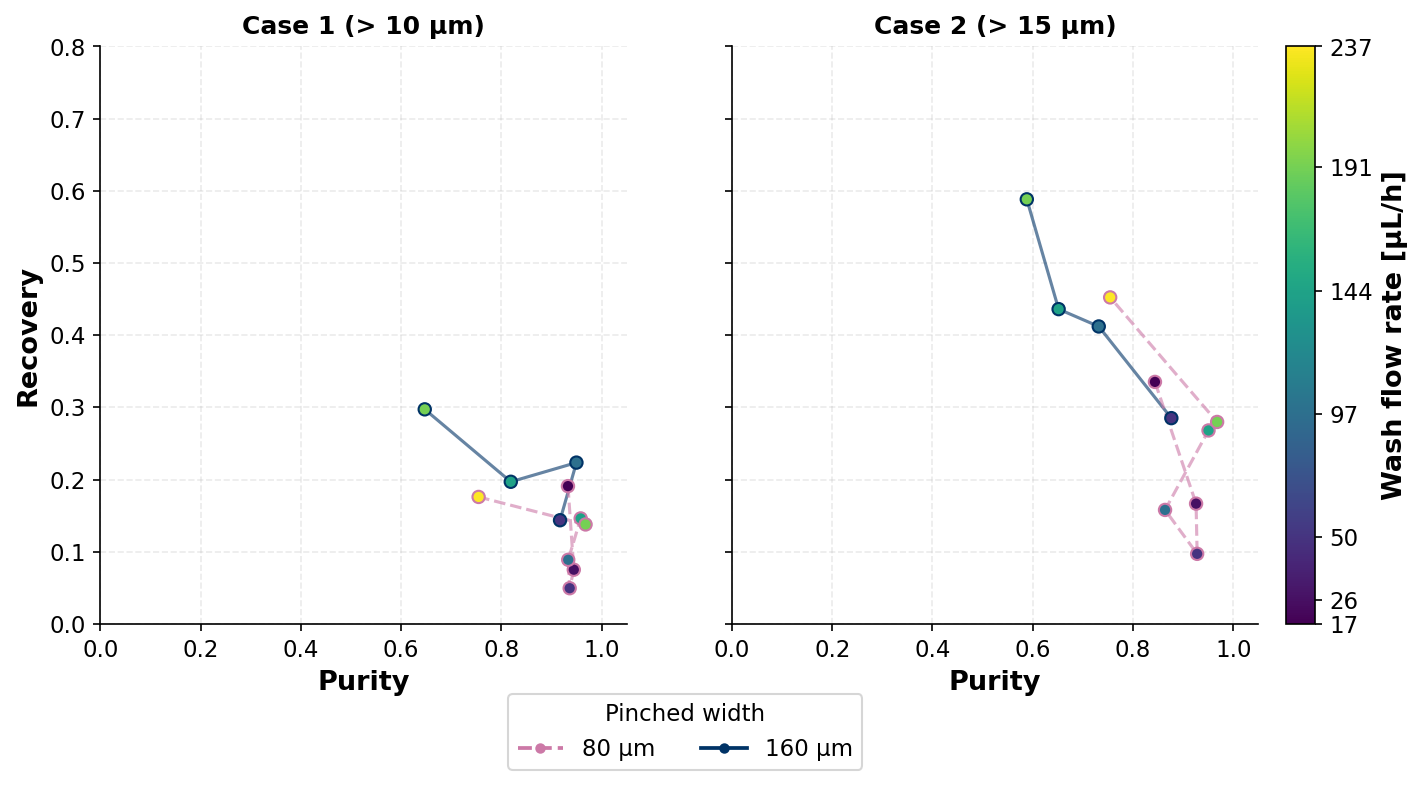

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
cases = list(GUV_THRESHOLDS.keys())

for ax, case in zip(axes, cases):
    df_case = perdev_summary[perdev_summary["case"] == case]
    for design in reversed(designs):
        color = DESIGN_COLOR[design]
        ls    = DESIGN_STYLE[design]["linestyle"]
        df_d  = df_case[df_case["design"] == design].sort_values("flow_v2")

        ax.plot(df_d["purity_mean"], df_d["recovery_mean"],
                color=color, linestyle=ls, linewidth=1.5, alpha=0.6, zorder=2)
        ax.scatter(df_d["purity_mean"], df_d["recovery_mean"],
                   c=df_d["flow_v2"], cmap="viridis",
                   vmin=min(wash_rates), vmax=max(wash_rates),
                   s=35, edgecolor=color, linewidth=1.0, zorder=3)

    ax.set_title(case, fontsize=12, fontweight="bold")
    ax.set_xlabel("Purity", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 0.8)
    ax.tick_params(labelsize=11)
axes[0].set_ylabel("Recovery", fontsize=13, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=min(wash_rates),
                                               vmax=max(wash_rates)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=1.0)
cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
cbar.set_ticks(wash_rates)
cbar.ax.tick_params(labelsize=11)

legend_handles_tr = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=4,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
fig.legend(handles=legend_handles_tr, title="Pinched width",
           title_fontsize=11, fontsize=11, framealpha=0.8,
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.45, -0.1))
#plt.tight_layout()
plt.savefig("fig_exp_purity_vs_recovery_perdev.pdf", bbox_inches="tight")
plt.show()

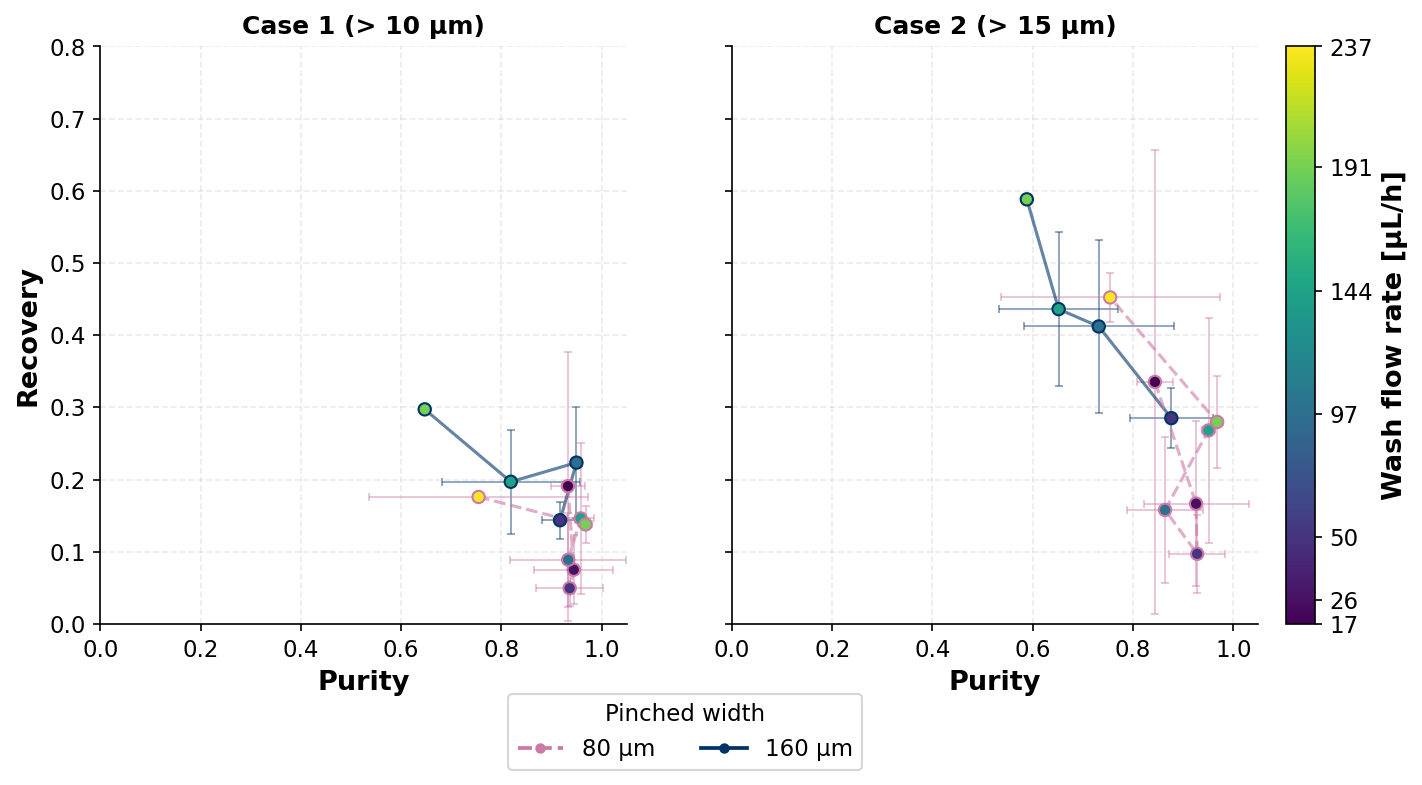

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
cases = list(GUV_THRESHOLDS.keys())

for ax, case in zip(axes, cases):
    df_case = perdev_summary[perdev_summary["case"] == case]
    for design in reversed(designs):
        color = DESIGN_COLOR[design]
        ls    = DESIGN_STYLE[design]["linestyle"]
        df_d  = df_case[df_case["design"] == design].sort_values("flow_v2")

        # Error bars (NaN errors -> 0 so single-device points have no bar)
        xerr = df_d["purity_sd"].fillna(0)
        yerr = df_d["recovery_sd"].fillna(0)
        ax.errorbar(df_d["purity_mean"], df_d["recovery_mean"],
                    xerr=xerr, yerr=yerr,
                    fmt="none",
                    ecolor=color, elinewidth=0.8,
                    capsize=2, capthick=0.8,
                    alpha=0.5, zorder=1)

        # Connecting line between conditions
        ax.plot(df_d["purity_mean"], df_d["recovery_mean"],
                color=color, linestyle=ls, linewidth=1.5, alpha=0.6, zorder=2)

        # Colour-coded markers on top
        ax.scatter(df_d["purity_mean"], df_d["recovery_mean"],
                   c=df_d["flow_v2"], cmap="viridis",
                   vmin=min(wash_rates), vmax=max(wash_rates),
                   s=35, edgecolor=color, linewidth=1.0, zorder=3)

    ax.set_title(case, fontsize=12, fontweight="bold")
    ax.set_xlabel("Purity", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 0.8)
    ax.tick_params(labelsize=11)
axes[0].set_ylabel("Recovery", fontsize=13, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=min(wash_rates),
                                               vmax=max(wash_rates)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=1.0)
cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
cbar.set_ticks(wash_rates)
cbar.ax.tick_params(labelsize=11)

legend_handles_tr = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=4,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
fig.legend(handles=legend_handles_tr, title="Pinched width",
           title_fontsize=11, fontsize=11, framealpha=0.8,
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.45, -0.1))
plt.savefig("fig_exp_purity_vs_recovery_perdev.pdf", bbox_inches="tight")
plt.show()

---
## 8. Comparison with COMSOL d★ prediction

Side-by-side comparison of the experimental d★ (per-device mean) and the COMSOL d★ prediction.

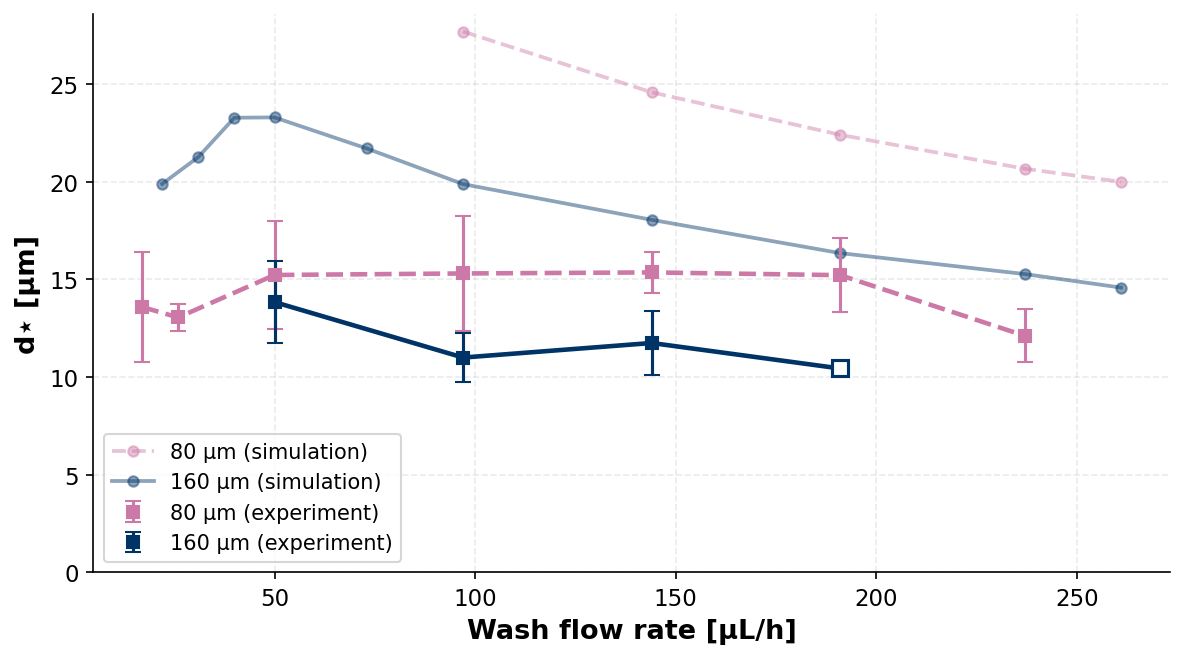

In [ ]:
comsol_thr_df = pd.read_csv(COMSOL_THR)

fig, ax = plt.subplots(figsize=(8, 4.5))

for design in designs:
    color = DESIGN_COLOR[design]
    ls    = DESIGN_STYLE[design]["linestyle"]
    label = DESIGN_STYLE[design]["label"]

    df_c = comsol_thr_df[
        (comsol_thr_df["design"] == design) &
        (~comsol_thr_df["artefact"]) &
        (comsol_thr_df["d_star"].notna())
    ]
    ax.plot(df_c["flow_wash"], df_c["d_star"],
            color=color, linestyle=ls, linewidth=1.8,
            marker="o", markersize=5, alpha=0.45,
            label=f"{label} (simulation)")

    df_e = dstar_summary[dstar_summary["design"] == design].sort_values("flow_v2")
    df_e_multi  = df_e[df_e["n_devices"] >= 2]
    df_e_single = df_e[df_e["n_devices"] == 1]

    ax.plot(df_e["flow_v2"], df_e["d_star_mean"],
            color=color, linestyle=ls, linewidth=2.2, zorder=3)
    if not df_e_multi.empty:
        ax.errorbar(df_e_multi["flow_v2"], df_e_multi["d_star_mean"],
                    yerr=df_e_multi["d_star_sd"],
                    color=color, linestyle="none",
                    marker="s", markersize=6, capsize=4, zorder=4,
                    label=f"{label} (experiment)")
    if not df_e_single.empty:
        ax.plot(df_e_single["flow_v2"], df_e_single["d_star_mean"],
                marker="s", markersize=8,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=1.5,
                linestyle="none", zorder=4)

ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
ax.set_ylabel("d⋆ [µm]", fontsize=13, fontweight="bold")
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig("fig_exp_vs_comsol_dstar.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# ── Particle counts per condition ─────────────────────────────────────────────
# Exclude artefacts so the table matches what was used in the analysis
exp_clean = exp_df[~exp_df["is_artefact"]]

particle_counts = (
    exp_clean
    .groupby(["design", "flow_v2_round"], as_index=False)
    .agg(
        n_particles_total = ("particle_id", "size"),
        n_waste           = ("branch", lambda s: (s == "waste").sum()),
        n_collection      = ("branch", lambda s: (s == "collection").sum()),
    )
    .rename(columns={"flow_v2_round": "flow_v2"})
)

# ── Merge with the per-condition recovery/purity summary ──────────────────────
summary_table = perdev_summary.merge(
    particle_counts,
    on=["design", "flow_v2"],
    how="left",
).sort_values(["case", "design", "flow_v2"]).reset_index(drop=True)

# Round for display
for col in ["purity_mean", "purity_sd", "recovery_mean", "recovery_sd"]:
    summary_table[col] = summary_table[col].round(3)

# Save raw CSV for inspection
summary_table.to_csv("table_perdev_summary.csv", index=False)
summary_table

,case,design,flow_v2,recovery_mean,recovery_sd,purity_mean,purity_sd,n_devices,n_particles_total,n_waste,n_collection
0,Case 1 (> 10 µm),160um_3out,50,0.144,0.025,0.917,0.037,2,3868,3635,233
1,Case 1 (> 10 µm),160um_3out,97,0.224,0.077,0.950,0.012,3,7204,6750,454
2,Case 1 (> 10 µm),160um_3out,144,0.197,0.072,0.819,0.138,3,5154,4851,303
3,Case 1 (> 10 µm),160um_3out,191,0.297,NaN,0.647,NaN,1,228,211,17
4,Case 1 (> 10 µm),80um_3out,17,0.191,0.186,0.933,0.034,2,1442,1408,34
5,Case 1 (> 10 µm),80um_3out,26,0.075,0.048,0.944,0.079,2,1563,1528,35
6,Case 1 (> 10 µm),80um_3out,50,0.050,0.025,0.936,0.067,2,3733,3654,79
7,Case 1 (> 10 µm),80um_3out,97,0.089,0.065,0.933,0.115,3,3111,2958,153
8,Case 1 (> 10 µm),80um_3out,144,0.146,0.104,0.958,0.027,3,2681,2522,159
9,Case 1 (> 10 µm),80um_3out,191,0.138,0.026,0.968,0.013,3,2701,2577,124


In [ ]:
# ── Build a display version ─────────────────────────────────
display_table = summary_table.copy()

# Combine mean ± sd into single cells
display_table["Purity"] = display_table.apply(
    lambda r: f"{r['purity_mean']:.2f} ± {r['purity_sd']:.2f}"
              if pd.notna(r["purity_sd"]) else f"{r['purity_mean']:.2f} (n=1)",
    axis=1,
)
display_table["Recovery"] = display_table.apply(
    lambda r: f"{r['recovery_mean']:.2f} ± {r['recovery_sd']:.2f}"
              if pd.notna(r["recovery_sd"]) else f"{r['recovery_mean']:.2f} (n=1)",
    axis=1,
)

display_table = display_table.rename(columns={
    "case":              "Case",
    "design":            "Design",
    "flow_v2":           "Wash flow [µL/h]",
    "n_devices":         "Devices",
    "n_particles_total": "Particles (total)",
    "n_waste":           "Waste",
    "n_collection":      "Collection",
})[
    ["Case", "Design", "Wash flow [µL/h]",
     "Devices", "Particles (total)", "Waste", "Collection",
     "Purity", "Recovery"]
]

display_table

,Case,Design,Wash flow [µL/h],Devices,Particles (total),Waste,Collection,Purity,Recovery
0,Case 1 (> 10 µm),160um_3out,50,2,3868,3635,233,0.92 ± 0.04,0.14 ± 0.03
1,Case 1 (> 10 µm),160um_3out,97,3,7204,6750,454,0.95 ± 0.01,0.22 ± 0.08
2,Case 1 (> 10 µm),160um_3out,144,3,5154,4851,303,0.82 ± 0.14,0.20 ± 0.07
3,Case 1 (> 10 µm),160um_3out,191,1,228,211,17,0.65 (n=1),0.30 (n=1)
4,Case 1 (> 10 µm),80um_3out,17,2,1442,1408,34,0.93 ± 0.03,0.19 ± 0.19
5,Case 1 (> 10 µm),80um_3out,26,2,1563,1528,35,0.94 ± 0.08,0.07 ± 0.05
6,Case 1 (> 10 µm),80um_3out,50,2,3733,3654,79,0.94 ± 0.07,0.05 ± 0.03
7,Case 1 (> 10 µm),80um_3out,97,3,3111,2958,153,0.93 ± 0.12,0.09 ± 0.07
8,Case 1 (> 10 µm),80um_3out,144,3,2681,2522,159,0.96 ± 0.03,0.15 ± 0.10
9,Case 1 (> 10 µm),80um_3out,191,3,2701,2577,124,0.97 ± 0.01,0.14 ± 0.03


In [ ]:
# ── Particle counts per condition, including GUV counts per case ──────────────
exp_clean = exp_df[~exp_df["is_artefact"]]

# Base counts (same for both cases, since they don't depend on the threshold)
particle_counts = (
    exp_clean
    .groupby(["design", "flow_v2_round"], as_index=False)
    .agg(
        n_particles_total = ("particle_id", "size"),
        n_waste           = ("branch", lambda s: (s == "waste").sum()),
        n_collection      = ("branch", lambda s: (s == "collection").sum()),
    )
    .rename(columns={"flow_v2_round": "flow_v2"})
)

# GUV counts per case (depend on the size threshold)
# Total GUVs (>= threshold) and GUVs recovered in the collection outlet
guv_count_rows = []
for case, threshold in GUV_THRESHOLDS.items():
    df_guv = exp_clean[exp_clean["width"] >= threshold]
    grouped = (
        df_guv
        .groupby(["design", "flow_v2_round"], as_index=False)
        .agg(
            n_guv_total      = ("particle_id", "size"),
            n_guv_collection = ("branch", lambda s: (s == "collection").sum()),
        )
        .rename(columns={"flow_v2_round": "flow_v2"})
    )
    grouped["case"] = case
    guv_count_rows.append(grouped)

guv_counts = pd.concat(guv_count_rows, ignore_index=True)

# ── Merge everything into perdev_summary ──────────────────────────────────────
summary_table = (
    perdev_summary
    .merge(particle_counts, on=["design", "flow_v2"], how="left")
    .merge(guv_counts,      on=["case", "design", "flow_v2"], how="left")
    .sort_values(["case", "design", "flow_v2"])
    .reset_index(drop=True)
)

# Fill any missing GUV counts with 0 (condition exists but no particles ≥ threshold)
summary_table["n_guv_total"]      = summary_table["n_guv_total"].fillna(0).astype(int)
summary_table["n_guv_collection"] = summary_table["n_guv_collection"].fillna(0).astype(int)

# Round purity/recovery for display
for col in ["purity_mean", "purity_sd", "recovery_mean", "recovery_sd"]:
    summary_table[col] = summary_table[col].round(3)

summary_table.to_csv("table_perdev_summary.csv", index=False)
summary_table

,case,design,flow_v2,recovery_mean,recovery_sd,purity_mean,purity_sd,n_devices,n_particles_total,n_waste,n_collection,n_guv_total,n_guv_collection
0,Case 1 (> 10 µm),160um_3out,50,0.144,0.025,0.917,0.037,2,3868,3635,233,1529,214
1,Case 1 (> 10 µm),160um_3out,97,0.224,0.077,0.950,0.012,3,7204,6750,454,1975,431
2,Case 1 (> 10 µm),160um_3out,144,0.197,0.072,0.819,0.138,3,5154,4851,303,1316,243
3,Case 1 (> 10 µm),160um_3out,191,0.297,NaN,0.647,NaN,1,228,211,17,37,11
4,Case 1 (> 10 µm),80um_3out,17,0.191,0.186,0.933,0.034,2,1442,1408,34,402,32
5,Case 1 (> 10 µm),80um_3out,26,0.075,0.048,0.944,0.079,2,1563,1528,35,414,32
6,Case 1 (> 10 µm),80um_3out,50,0.050,0.025,0.936,0.067,2,3733,3654,79,1395,76
7,Case 1 (> 10 µm),80um_3out,97,0.089,0.065,0.933,0.115,3,3111,2958,153,1358,152
8,Case 1 (> 10 µm),80um_3out,144,0.146,0.104,0.958,0.027,3,2681,2522,159,1034,154
9,Case 1 (> 10 µm),80um_3out,191,0.138,0.026,0.968,0.013,3,2701,2577,124,901,120


In [ ]:
# ── Display version ─────────────────────────────────────────
display_table = summary_table.copy()

# Compact case label: "Case 1 (> 10 µm)" -> "1"
display_table["case"] = display_table["case"].str.extract(r"Case\s*(\d+)")

# Compact design label: "160um_3out" -> "160um-3out"
display_table["design"] = display_table["design"].str.replace("_", "-", regex=False)

display_table["Purity"] = display_table.apply(
    lambda r: f"{r['purity_mean']:.2f} ± {r['purity_sd']:.2f}"
              if pd.notna(r["purity_sd"]) else f"{r['purity_mean']:.2f} (n=1)",
    axis=1,
)
display_table["Recovery"] = display_table.apply(
    lambda r: f"{r['recovery_mean']:.2f} ± {r['recovery_sd']:.2f}"
              if pd.notna(r["recovery_sd"]) else f"{r['recovery_mean']:.2f} (n=1)",
    axis=1,
)

display_table = display_table.rename(columns={
    "case":              "Case",
    "design":            "Design",
    "flow_v2":           "Wash flow [µL/h]",
    "n_devices":         "Devices",
    "n_particles_total": "Particles (total)",
    "n_waste":           "Waste",
    "n_collection":      "Collection",
    "n_guv_total":       "GUVs (total)",
    "n_guv_collection":  "GUVs (coll)",
})[
    ["Case", "Design", "Wash flow [µL/h]",
     "Devices", "Particles (total)", "Waste", "Collection",
     "GUVs (total)", "GUVs (coll)",
     "Purity", "Recovery"]
]

display_table

,Case,Design,Wash flow [µL/h],Devices,Particles (total),Waste,Collection,GUVs (total),GUVs (coll),Purity,Recovery
0,1,160um-3out,50,2,3868,3635,233,1529,214,0.92 ± 0.04,0.14 ± 0.03
1,1,160um-3out,97,3,7204,6750,454,1975,431,0.95 ± 0.01,0.22 ± 0.08
2,1,160um-3out,144,3,5154,4851,303,1316,243,0.82 ± 0.14,0.20 ± 0.07
3,1,160um-3out,191,1,228,211,17,37,11,0.65 (n=1),0.30 (n=1)
4,1,80um-3out,17,2,1442,1408,34,402,32,0.93 ± 0.03,0.19 ± 0.19
5,1,80um-3out,26,2,1563,1528,35,414,32,0.94 ± 0.08,0.07 ± 0.05
6,1,80um-3out,50,2,3733,3654,79,1395,76,0.94 ± 0.07,0.05 ± 0.03
7,1,80um-3out,97,3,3111,2958,153,1358,152,0.93 ± 0.12,0.09 ± 0.07
8,1,80um-3out,144,3,2681,2522,159,1034,154,0.96 ± 0.03,0.15 ± 0.10
9,1,80um-3out,191,3,2701,2577,124,901,120,0.97 ± 0.01,0.14 ± 0.03


In [ ]:
# ── Export as LaTeX ───────────────────────────────────────────────────────────
latex = display_table.to_latex(
    index=False,
    column_format="llrrrrrrrll",
    caption=("Per-condition summary of experimental PFF results. "
             "Particle counts exclude artefacts. "
             "GUVs are defined as particles with apparent diameter "
             "above the case-specific threshold (10\\,µm for Case 1, "
             "15\\,µm for Case 2). "
             "Purity and recovery are reported as mean $\\pm$ standard deviation "
             "across replicate devices; conditions with a single device are marked $(n=1)$."),
    label="tab:perdev_summary",
    escape=False,
)

with open("table_perdev_summary.tex", "w") as f:
    f.write(latex)

print(latex)

\begin{table}
\caption{Per-condition summary of experimental PFF results. Particle counts exclude artefacts. GUVs are defined as particles with apparent diameter above the case-specific threshold (10\,µm for Case 1, 15\,µm for Case 2). Purity and recovery are reported as mean $\pm$ standard deviation across replicate devices; conditions with a single device are marked $(n=1)$.}
\label{tab:perdev_summary}
\begin{tabular}{llrrrrrrrll}
\toprule
Case & Design & Wash flow [µL/h] & Devices & Particles (total) & Waste & Collection & GUVs (total) & GUVs (coll) & Purity & Recovery \\
\midrule
1 & 160um-3out & 50 & 2 & 3868 & 3635 & 233 & 1529 & 214 & 0.92 ± 0.04 & 0.14 ± 0.03 \\
1 & 160um-3out & 97 & 3 & 7204 & 6750 & 454 & 1975 & 431 & 0.95 ± 0.01 & 0.22 ± 0.08 \\
1 & 160um-3out & 144 & 3 & 5154 & 4851 & 303 & 1316 & 243 & 0.82 ± 0.14 & 0.20 ± 0.07 \\
1 & 160um-3out & 191 & 1 & 228 & 211 & 17 & 37 & 11 & 0.65 (n=1) & 0.30 (n=1) \\
1 & 80um-3out & 17 & 2 & 1442 & 1408 & 34 & 402 & 32 & 0.93 ± 0

In [ ]:
# ── Export as LaTeX with auto-wrapping column headers ─────────────────────────
latex = display_table.to_latex(
    index=False,
    column_format="ll p{1.3cm} r p{1.4cm} r r p{1.2cm} p{1.2cm} l l",
    caption=("Per-condition summary of experimental PFF results. "
             "Particle counts exclude artefacts. "
             "GUVs are defined as particles with apparent diameter "
             "above the case-specific threshold (10\\,µm for Case 1, "
             "15\\,µm for Case 2). "
             "Purity and recovery are reported as mean $\\pm$ standard deviation "
             "across replicate devices; conditions with a single device are marked $(n=1)$."),
    label="tab:perdev_summary",
    escape=False,
)

with open("table_perdev_summary.tex", "w") as f:
    f.write(latex)

print(latex)

\begin{table}
\caption{Per-condition summary of experimental PFF results. Particle counts exclude artefacts. GUVs are defined as particles with apparent diameter above the case-specific threshold (10\,µm for Case 1, 15\,µm for Case 2). Purity and recovery are reported as mean $\pm$ standard deviation across replicate devices; conditions with a single device are marked $(n=1)$.}
\label{tab:perdev_summary}
\begin{tabular}{ll p{1.3cm} r p{1.4cm} r r p{1.2cm} p{1.2cm} l l}
\toprule
Case & Design & Wash flow [µL/h] & Devices & Particles (total) & Waste & Collection & GUVs (total) & GUVs (coll) & Purity & Recovery \\
\midrule
1 & 160um-3out & 50 & 2 & 3868 & 3635 & 233 & 1529 & 214 & 0.92 ± 0.04 & 0.14 ± 0.03 \\
1 & 160um-3out & 97 & 3 & 7204 & 6750 & 454 & 1975 & 431 & 0.95 ± 0.01 & 0.22 ± 0.08 \\
1 & 160um-3out & 144 & 3 & 5154 & 4851 & 303 & 1316 & 243 & 0.82 ± 0.14 & 0.20 ± 0.07 \\
1 & 160um-3out & 191 & 1 & 228 & 211 & 17 & 37 & 11 & 0.65 (n=1) & 0.30 (n=1) \\
1 & 80um-3out & 17 & 2 & 1

In [ ]:
# ── Display version ─────────────────────────────────────────
display_table = summary_table.copy()

# Compact case label: "Case 1 (> 10 µm)" -> "1"
display_table["case"] = display_table["case"].str.extract(r"Case\s*(\d+)")

# Compact design label: "160um_3out" -> "160um-3out"
display_table["design"] = display_table["design"].str.replace("_", "-", regex=False)

display_table = display_table.rename(columns={
    "case":              "Case",
    "design":            "Design",
    "flow_v2":           "Wash flow [µL/h]",
    "n_devices":         "Devices",
    "n_particles_total": "Particles (total)",
    "n_waste":           "Waste",
    "n_collection":      "Collection",
    "n_guv_total":       "GUVs (total)",
    "n_guv_collection":  "GUVs (coll)",
})[
    ["Case", "Design", "Wash flow [µL/h]",
     "Devices", "Particles (total)", "Waste", "Collection",
     "GUVs (total)", "GUVs (coll)"]
]

display_table

,Case,Design,Wash flow [µL/h],Devices,Particles (total),Waste,Collection,GUVs (total),GUVs (coll)
0,1,160um-3out,50,2,3868,3635,233,1529,214
1,1,160um-3out,97,3,7204,6750,454,1975,431
2,1,160um-3out,144,3,5154,4851,303,1316,243
3,1,160um-3out,191,1,228,211,17,37,11
4,1,80um-3out,17,2,1442,1408,34,402,32
5,1,80um-3out,26,2,1563,1528,35,414,32
6,1,80um-3out,50,2,3733,3654,79,1395,76
7,1,80um-3out,97,3,3111,2958,153,1358,152
8,1,80um-3out,144,3,2681,2522,159,1034,154
9,1,80um-3out,191,3,2701,2577,124,901,120


In [ ]:
# ── Export as LaTeX with auto-wrapping column headers ─────────────────────────
latex = display_table.to_latex(
    index=False,
    column_format="ll p{1.3cm} r p{1.4cm} r r p{1.2cm} p{1.2cm}",
    caption=("Per-condition summary of experimental PFF results. "
             "Particle counts exclude artefacts. "
             "GUVs are defined as particles with apparent diameter "
             "above the case-specific threshold (10\\,µm for Case 1, "
             "15\\,µm for Case 2)."),
    label="tab:perdev_summary",
    escape=False,
)

with open("table_perdev_summary.tex", "w") as f:
    f.write(latex)

print(latex)

\begin{table}
\caption{Per-condition summary of experimental PFF results. Particle counts exclude artefacts. GUVs are defined as particles with apparent diameter above the case-specific threshold (10\,µm for Case 1, 15\,µm for Case 2).}
\label{tab:perdev_summary}
\begin{tabular}{ll p{1.3cm} r p{1.4cm} r r p{1.2cm} p{1.2cm}}
\toprule
Case & Design & Wash flow [µL/h] & Devices & Particles (total) & Waste & Collection & GUVs (total) & GUVs (coll) \\
\midrule
1 & 160um-3out & 50 & 2 & 3868 & 3635 & 233 & 1529 & 214 \\
1 & 160um-3out & 97 & 3 & 7204 & 6750 & 454 & 1975 & 431 \\
1 & 160um-3out & 144 & 3 & 5154 & 4851 & 303 & 1316 & 243 \\
1 & 160um-3out & 191 & 1 & 228 & 211 & 17 & 37 & 11 \\
1 & 80um-3out & 17 & 2 & 1442 & 1408 & 34 & 402 & 32 \\
1 & 80um-3out & 26 & 2 & 1563 & 1528 & 35 & 414 & 32 \\
1 & 80um-3out & 50 & 2 & 3733 & 3654 & 79 & 1395 & 76 \\
1 & 80um-3out & 97 & 3 & 3111 & 2958 & 153 & 1358 & 152 \\
1 & 80um-3out & 144 & 3 & 2681 & 2522 & 159 & 1034 & 154 \\
1 & 80um-3out & 

---
## 9. Export summary tables

In [ ]:
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/MEP")

pooled_dstar.to_csv  (OUTPUT_DIR / "exp_pooled_dstar.csv",      index=False)
dstar_perdev.to_csv  (OUTPUT_DIR / "exp_dstar_perdev.csv",      index=False)
dstar_summary.to_csv (OUTPUT_DIR / "exp_dstar_summary.csv",     index=False)
perdev_metrics.to_csv(OUTPUT_DIR / "exp_metrics_perdev.csv",    index=False)
perdev_summary.to_csv(OUTPUT_DIR / "exp_metrics_summary.csv",   index=False)

print("Saved 5 summary tables.")